In [1]:
import argparse
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


# Dataset Path

In [61]:
TRAIN_PATH = "./dataset/train.csv"
TEST_PATH = "./dataset/test.csv"
SAMPLE_SUBMISSION_PATH = "./dataset/sample_submission.csv"

PLOT_PATH = "./plots"

TARGET_LABELS = {0: "No (0)", 1: "Yes (1)"}

NUM_COLS = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time",
]
CAT_COLS = ["gender", "stress_level", "academic_work_impact"] 

# Load data

In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUBMISSION_PATH)

os.makedirs(PLOT_PATH, exist_ok=True)

TARGET = "addicted_label"
ID_COL = "id"

print("=" * 70)
print("SHAPES")
print("=" * 70)
print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"sample_submission: {sample_sub.shape}")

SHAPES
train: (691369, 14)
test : (296302, 13)
sample_submission: (296302, 2)


## Check for NaN values

In [4]:
# See what values are in the column and how many are missing
print(train[TARGET].value_counts(dropna=False))
print(f"Missing before map: {train[TARGET].isna().sum()}")

# Fill missing values with a default (e.g., 0 = "No")
train[TARGET] = train[TARGET].fillna(0).astype(int)

# Check what became NaN
print(f"Missing after map: {train[TARGET].isna().sum()}")

addicted_label
1    490474
0    200895
Name: count, dtype: int64
Missing before map: 0
Missing after map: 0


# Basic structure

## Train Info

In [5]:
print("\n" + "=" * 70)
print("TRAIN HEAD")
print("=" * 70)
print(train.head())

print("\n" + "=" * 70)
print("TRAIN INFO (dtypes, non-null counts)")
print("=" * 70)
train.info()


TRAIN HEAD
   id   age  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  weekend_screen_time  gender stress_level  \
0   0  24.0                      NaN                1.83          1.59              2.11         7.46                  122.0               38.0                 8.63    Male       Medium   
1   1  19.0                     5.97                1.08           NaN              3.03         8.22                   76.0               19.0                  NaN  Female       Medium   
2   2  18.0                     5.09                 NaN           NaN               NaN         6.25                  134.0               60.0                 7.47  Female          Low   
3   3  21.0                     6.42                1.26          1.42              3.36         8.85                  112.0               94.0                 8.66   Other          Low   
4   4  26.0                    11.20       

## Test Info

In [6]:
print("\n" + "=" * 70)
print("TEST HEAD")
print("=" * 70)
print(test.head())

print("\n" + "=" * 70)
print("TEST INFO")
print("=" * 70)
test.info()


TEST HEAD
       id   age  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  weekend_screen_time  gender stress_level  \
0  691369  30.0                     9.34                 NaN          0.77              4.09         7.15                  153.0               16.0                  NaN   Other       Medium   
1  691370   NaN                      NaN                1.91           NaN              1.20         8.67                  239.0              148.0                10.68  Female         High   
2  691371  26.0                     8.48                3.64           NaN              3.39         7.47                  106.0              123.0                  NaN    Male          NaN   
3  691372  20.0                     8.37                2.99          1.69              2.53         5.45                  178.0               55.0                 9.88    Male         High   
4  691373  25.0         

# Missing values

In [7]:
print("\n" + "=" * 70)
print("MISSING VALUES - TRAIN (% of rows)")
print("=" * 70)
missing_pct = (train.isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

rows_with_any_missing = train.isnull().any(axis=1).mean() * 100
print(f"\nRows with >=1 missing value: {rows_with_any_missing:.2f}%")

print("\n" + "=" * 70)
print("MISSING VALUES - TEST (% of rows)")
print("=" * 70)
missing_pct_test = (test.isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct_test[missing_pct_test > 0])


MISSING VALUES - TRAIN (% of rows)
social_media_hours         19.381112
gaming_hours               18.343461
weekend_screen_time        16.208855
daily_screen_time_hours    13.864376
app_opens_per_day          11.673940
notifications_per_day       9.775388
stress_level                7.976638
work_study_hours            7.451592
sleep_hours                 6.433612
academic_work_impact        6.396584
gender                      4.199494
age                         4.184307
dtype: float64

Rows with >=1 missing value: 61.06%

MISSING VALUES - TEST (% of rows)
gaming_hours               20.053864
weekend_screen_time        17.109908
social_media_hours         15.996180
notifications_per_day      11.549365
daily_screen_time_hours    11.065737
work_study_hours            9.374557
academic_work_impact        8.680670
app_opens_per_day           8.675271
sleep_hours                 7.578417
stress_level                6.623647
age                         5.783964
gender                    

## Does missingness itself carry signal? (missing indicator vs target)


In [8]:
from scipy import stats

print("\n" + "=" * 70)
print("DOES MISSINGNESS CORRELATE WITH THE TARGET?")
print("=" * 70)
for c in NUM_COLS + CAT_COLS:
    if train[c].isnull().sum() == 0:
        continue
    is_missing = train[c].isnull().astype(int)
    rate_missing = train.loc[is_missing == 1, TARGET].mean()
    rate_present = train.loc[is_missing == 0, TARGET].mean()
    # simple proportions z-test
    stat, p = stats.ttest_ind(
        train.loc[is_missing == 1, TARGET],
        train.loc[is_missing == 0, TARGET],
        equal_var=False,
    )
    print(f"{c:28s} missing_rate={is_missing.mean():.3f}  "
            f"target|missing={rate_missing:.4f}  target|present={rate_present:.4f}  "
            f"p={p:.4f}")

print("\nRow-level missing count vs target:")
train["_missing_count"] = train[NUM_COLS + CAT_COLS].isnull().sum(axis=1)
print(train.groupby("_missing_count")[TARGET].agg(["mean", "count"]))
train.drop(columns=["_missing_count"], inplace=True)


DOES MISSINGNESS CORRELATE WITH THE TARGET?
age                          missing_rate=0.042  target|missing=0.7134  target|present=0.7093  p=0.1265
daily_screen_time_hours      missing_rate=0.139  target|missing=0.7113  target|present=0.7091  p=0.1674
social_media_hours           missing_rate=0.194  target|missing=0.7094  target|present=0.7094  p=0.9930
gaming_hours                 missing_rate=0.183  target|missing=0.7105  target|present=0.7092  p=0.3477
work_study_hours             missing_rate=0.075  target|missing=0.7106  target|present=0.7093  p=0.5255
sleep_hours                  missing_rate=0.064  target|missing=0.7134  target|present=0.7092  p=0.0568
notifications_per_day        missing_rate=0.098  target|missing=0.7102  target|present=0.7093  p=0.6218
app_opens_per_day            missing_rate=0.117  target|missing=0.7128  target|present=0.7090  p=0.0248
weekend_screen_time          missing_rate=0.162  target|missing=0.7107  target|present=0.7092  p=0.3215
gender             

# Duplicates

In [9]:
print("\n" + "=" * 70)
print("DUPLICATES")
print("=" * 70)
print(f"Duplicate rows in train: {train.duplicated().shape[0] - train.drop_duplicates().shape[0]}")
print(f"Duplicate ids in train : {train[ID_COL].duplicated().sum()}")
print(f"Duplicate ids in test  : {test[ID_COL].duplicated().sum()}")


DUPLICATES
Duplicate rows in train: 0
Duplicate ids in train : 0
Duplicate ids in test  : 0


# Target distribution (class balance)


TARGET DISTRIBUTION
distribution count:
addicted_label
0    200895
1    490474

distribution percentage:
addicted_label
0    29.058 %
1    70.942 %
Name: proportion, dtype: str

Total samples: 691,369


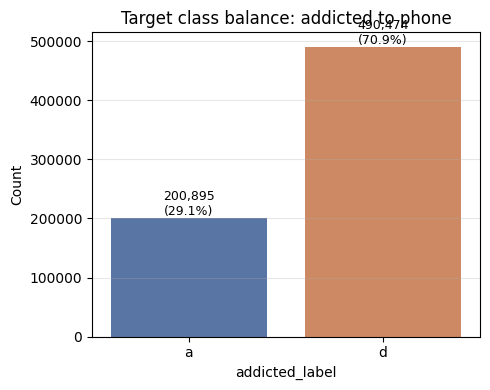

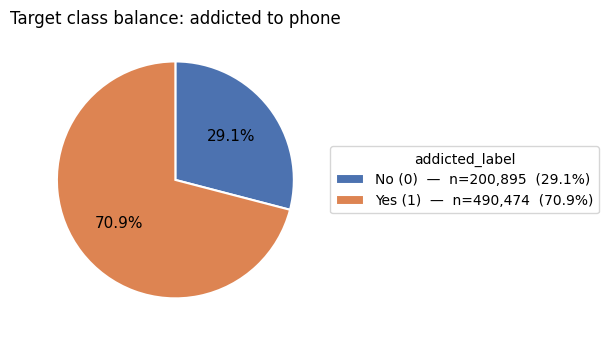

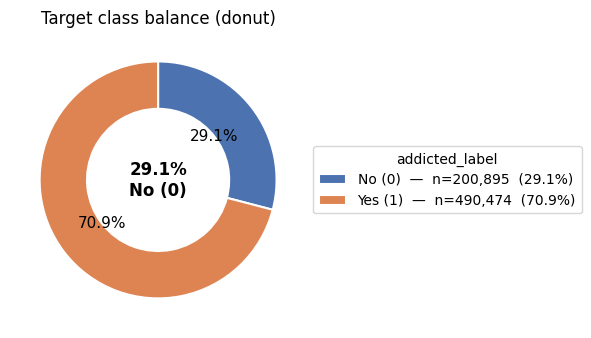

In [63]:
import seaborn as sns

#  Print summary
print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

counts = train[TARGET].value_counts().sort_index()
props  = train[TARGET].value_counts(normalize=True).sort_index()

print("distribution count:")
print(counts.to_string())
print("\ndistribution percentage:")
print((props * 100).round(3).astype(str) + " %")
print(f"\nTotal samples: {len(train):,}")

# COUNT PLOT (existing, cleaned up)
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=train, ax=ax,
              hue=TARGET, palette={0: "#4C72B0", 1: "#DD8452"},
              legend=False)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([TARGET[k] for k in counts.index])
ax.set_xlabel(f"{TARGET}")
ax.set_ylabel("Count")

# annotate bars with count + %
for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v, f"{v:,}\n({v/len(train)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Target class balance: addicted to phone")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# PIE CHART
fig, ax = plt.subplots(figsize=(6, 6))
labels = [TARGET_LABELS[k] for k in counts.index]
colors = ["#4C72B0", "#DD8452"]

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11),
)

# legend with count + % so readers get both numbers
legend_labels = [
    f"{TARGET_LABELS[k]}  —  n={counts[k]:,}  ({counts[k]/len(train)*100:.1f}%)"
    for k in counts.index
]
ax.legend(wedges, legend_labels,
          title=f"{TARGET}", loc="center left",
          bbox_to_anchor=(1.0, 0.5), fontsize=10)

ax.set_title("Target class balance: addicted to phone", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# donut variant (nicer for a 2-class target)
fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11),
)
maj_pct = counts.iloc[0] / len(train) * 100
ax.text(0, 0, f"{maj_pct:.1f}%\n{TARGET_LABELS[counts.index[0]]}",
        ha="center", va="center", fontsize=12, fontweight="bold")

ax.legend(wedges, legend_labels, title=f"{TARGET}",
          loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)
ax.set_title("Target class balance (donut)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance_donut.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# Identify column types

In [11]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "string", "str"]).columns.tolist()

for c in [ID_COL, TARGET]:
    if c in num_cols:
        num_cols.remove(c)
    if c in cat_cols:
        cat_cols.remove(c)

print("\n" + "=" * 70)
print("COLUMN TYPES")
print("=" * 70)
print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical/object columns ({len(cat_cols)}): {cat_cols}")


COLUMN TYPES
Numeric columns (9): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical/object columns (3): ['gender', 'stress_level', 'academic_work_impact']


# Numeric feature summary

In [12]:
print("\n" + "=" * 70)
print("NUMERIC SUMMARY - TRAIN")
print("=" * 70)
print(train[num_cols].describe().T)


NUMERIC SUMMARY - TRAIN
                            count        mean        std    min    25%     50%     75%     max
age                      662440.0   26.615408   5.153162  18.00  22.00   27.00   31.00   35.00
daily_screen_time_hours  595515.0    7.640865   2.721446   0.50   5.48    7.77    9.84   15.00
social_media_hours       557374.0    2.471038   1.316137   0.00   1.45    2.31    3.37    8.00
gaming_hours             564548.0    1.459265   0.934552   0.00   0.70    1.33    2.09    4.00
work_study_hours         639851.0    2.366971   1.258797   0.00   1.36    2.20    3.20    6.00
sleep_hours              646889.0    6.804334   1.234512   4.50   5.78    6.80    7.87    9.00
notifications_per_day    623785.0  145.894900  65.917556  20.00  93.00  150.00  204.00  250.00
app_opens_per_day        610659.0  102.636781  48.093970  15.00  64.00  104.00  145.00  180.00
weekend_screen_time      579306.0    9.479866   2.856006   0.51   7.28    9.58   11.75   17.56


# Categorical feature summary (unique values / cardinality)

In [13]:
print("\n" + "=" * 70)
print("CATEGORICAL SUMMARY - TRAIN")
print("=" * 70)
for c in cat_cols:
    n_unique = train[c].nunique()
    print(f"\n{c}  (unique values: {n_unique})")
    print(train[c].value_counts(dropna=False))



CATEGORICAL SUMMARY - TRAIN

gender  (unique values: 3)
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

stress_level  (unique values: 3)
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

academic_work_impact  (unique values: 2)
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


# Check train/test consistency for categorical columns(values in test not seen in train can break some encoders)


TRAIN vs TEST CATEGORY CONSISTENCY
gender: only_in_test=none, only_in_train=none
stress_level: only_in_test=none, only_in_train=none
academic_work_impact: only_in_test=none, only_in_train=none


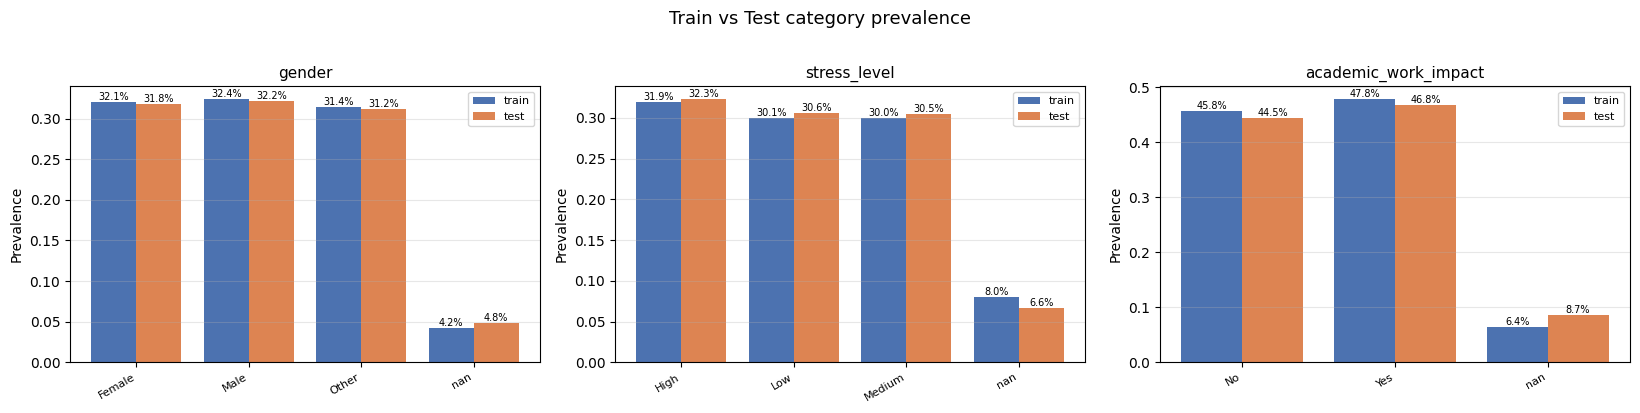

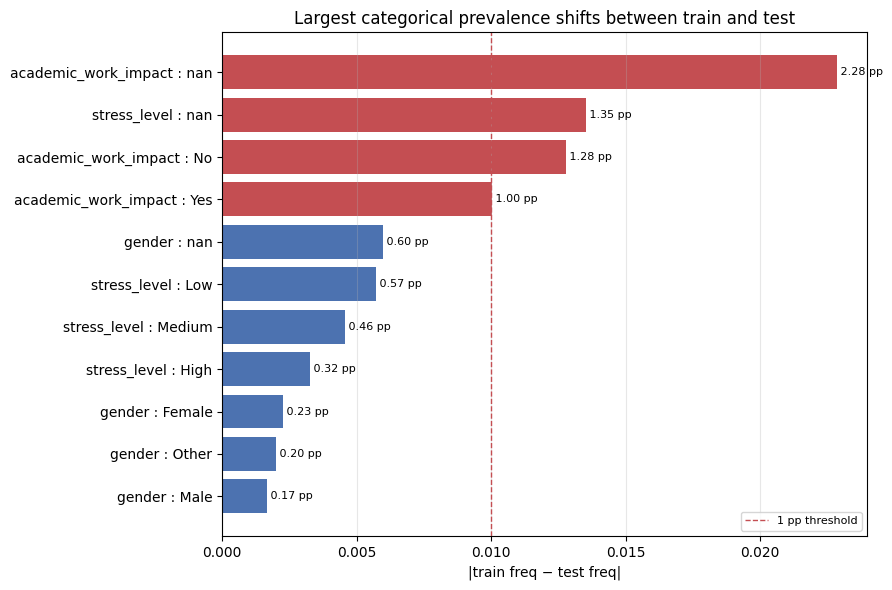

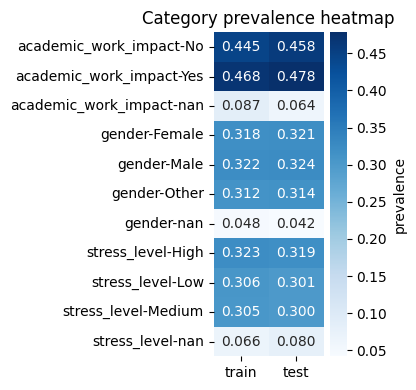


Top 10 category prevalence gaps (train vs test):
             feature category  train_freq  test_freq  abs_diff
academic_work_impact      nan      0.0640     0.0868    0.0228
        stress_level      nan      0.0798     0.0662    0.0135
academic_work_impact       No      0.4579     0.4451    0.0128
academic_work_impact      Yes      0.4781     0.4681    0.0100
              gender      nan      0.0420     0.0480    0.0060
        stress_level      Low      0.3005     0.3063    0.0057
        stress_level   Medium      0.3002     0.3048    0.0046
        stress_level     High      0.3195     0.3227    0.0032
              gender   Female      0.3205     0.3182    0.0023
              gender    Other      0.3140     0.3120    0.0020
              gender     Male      0.3235     0.3218    0.0017


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Consistency check + collect stats for plotting
print("\n" + "=" * 70)
print("TRAIN vs TEST CATEGORY CONSISTENCY")
print("=" * 70)

stats_rows = []
for c in cat_cols:
    train_vals = set(train[c].dropna().unique())
    test_vals  = set(test[c].dropna().unique())
    only_in_test  = test_vals - train_vals
    only_in_train = train_vals - test_vals
    print(f"{c}: only_in_test={only_in_test or 'none'}, "
          f"only_in_train={only_in_train or 'none'}")

    # per-category frequency in each split
    tr_freq = train[c].value_counts(normalize=True, dropna=False)
    te_freq = test[c].value_counts(normalize=True,  dropna=False)
    for cat in sorted(set(tr_freq.index) | set(te_freq.index), key=str):
        stats_rows.append({
            "feature":    c,
            "category":   str(cat),
            "train_freq": tr_freq.get(cat, 0.0),
            "test_freq":  te_freq.get(cat, 0.0),
        })

cons_df = pd.DataFrame(stats_rows)

# GROUPED BAR CHART
n_feats = len(cat_cols)
n_cols  = min(3, n_feats)
n_rows  = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, cat_cols):
    sub = cons_df[cons_df["feature"] == c].copy()
    x = np.arange(len(sub))
    w = 0.4

    ax.bar(x - w/2, sub["train_freq"], w, label="train", color="#4C72B0")
    ax.bar(x + w/2, sub["test_freq"],  w, label="test",  color="#DD8452")

    # label each bar with %
    for xi, v in zip(x - w/2, sub["train_freq"]):
        ax.text(xi, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)
    for xi, v in zip(x + w/2, sub["test_freq"]):
        ax.text(xi, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["category"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Prevalence")
    ax.set_title(c, fontsize=11)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)

# hide unused subplots
for ax in axes[n_feats:]:
    ax.axis("off")

plt.suptitle("Train vs Test category prevalence", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_bars.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# ABSOLUTE DIFFERENCE BAR — sorted by max |Δfrequency|
cons_df["abs_diff"] = (cons_df["train_freq"] - cons_df["test_freq"]).abs()
worst = cons_df.sort_values("abs_diff", ascending=False).head(15).copy()
worst["label"] = worst["feature"] + " : " + worst["category"]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C44E52" if d > 0.01 else "#4C72B0" for d in worst["abs_diff"]]
ax.barh(worst["label"], worst["abs_diff"], color=colors)
ax.invert_yaxis()

for i, v in enumerate(worst["abs_diff"]):
    ax.text(v, i, f" {v*100:.2f} pp", va="center", fontsize=8)

ax.axvline(0.01, color="#C44E52", ls="--", lw=1, label="1 pp threshold")
ax.set_xlabel("|train freq − test freq|")
ax.set_title("Largest categorical prevalence shifts between train and test")
ax.grid(alpha=0.3, axis="x")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_diff.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# HEATMAP — all categories × {train, test}
pivot = cons_df.pivot_table(
    index=["feature", "category"], values=["train_freq", "test_freq"]
)
pivot.columns = ["train", "test"]

fig, ax = plt.subplots(figsize=(4, max(4, 0.35 * len(pivot))))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues",
            cbar_kws={"label": "prevalence"}, ax=ax)
ax.set_title("Category prevalence heatmap")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# SUMMARY TABLE — worst offenders
print("\nTop 10 category prevalence gaps (train vs test):")
print(worst[["feature", "category", "train_freq", "test_freq", "abs_diff"]]
      .round(4).to_string(index=False))

cons_df.to_csv(f"{PLOT_PATH}/cat_consistency.csv", index=False)

# Distribution plots for numeric features (by target)

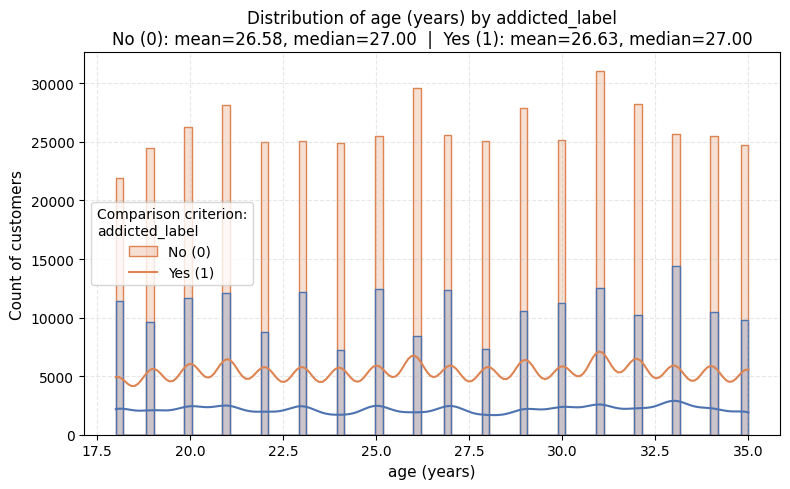

Saved: ./plots\hist_age_by_addicted_label.png


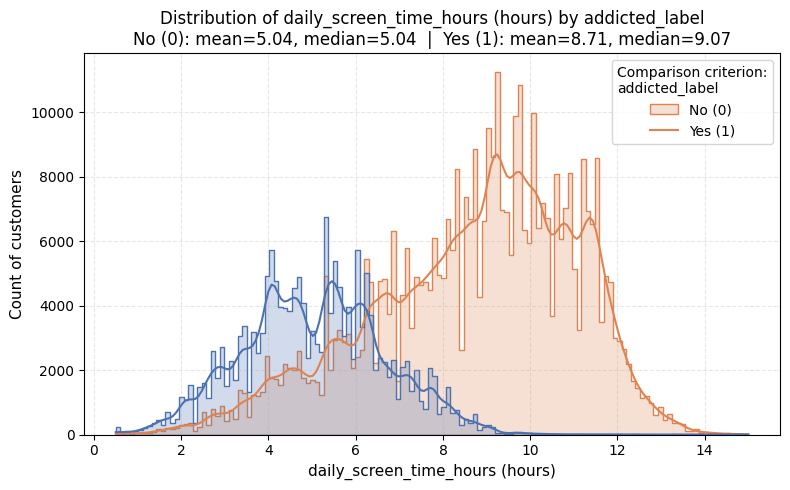

Saved: ./plots\hist_daily_screen_time_hours_by_addicted_label.png


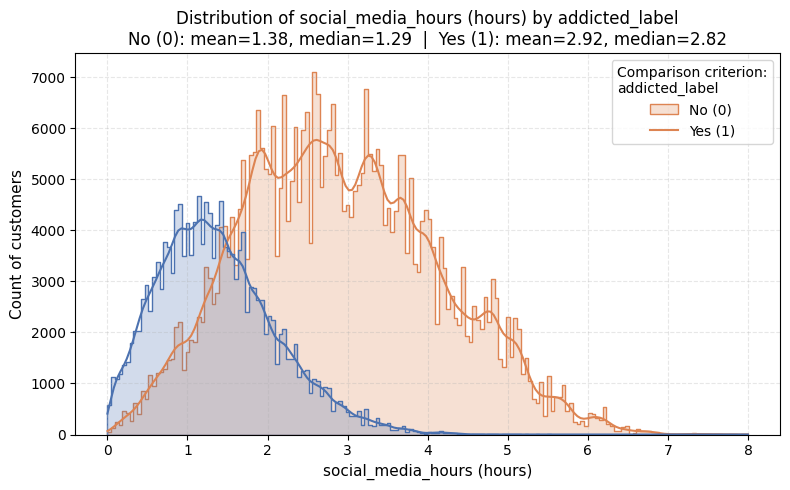

Saved: ./plots\hist_social_media_hours_by_addicted_label.png


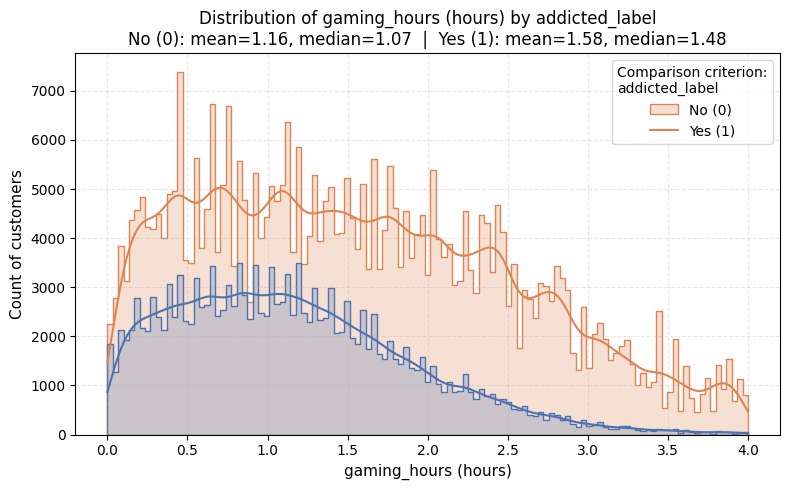

Saved: ./plots\hist_gaming_hours_by_addicted_label.png


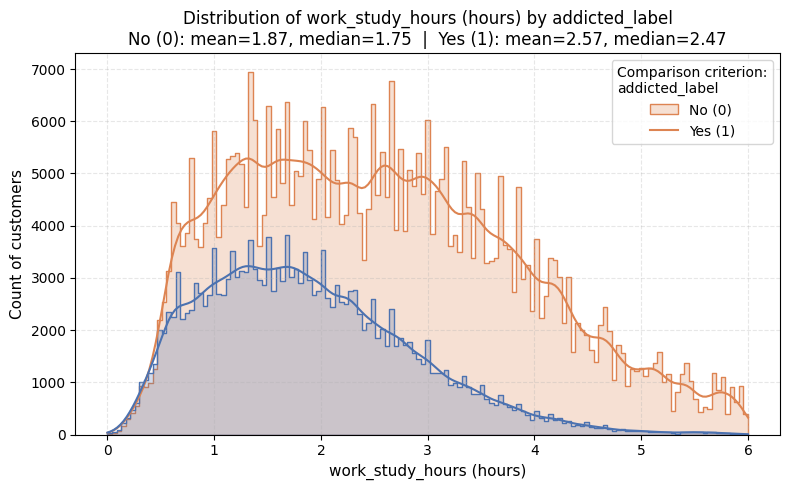

Saved: ./plots\hist_work_study_hours_by_addicted_label.png


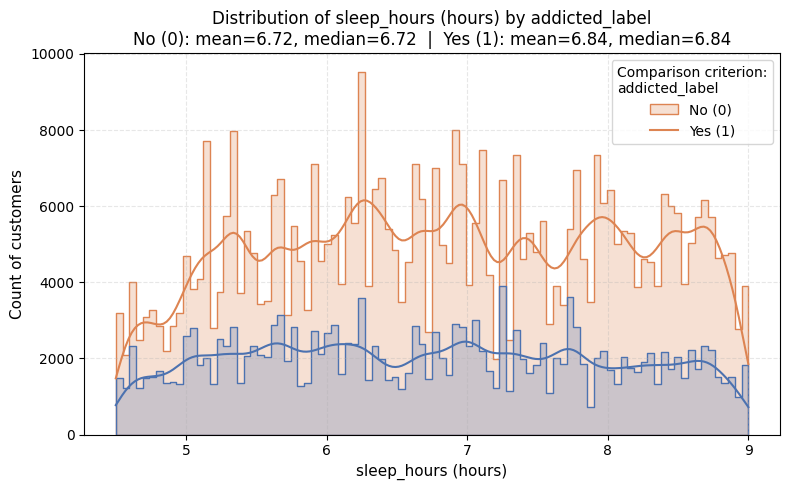

Saved: ./plots\hist_sleep_hours_by_addicted_label.png


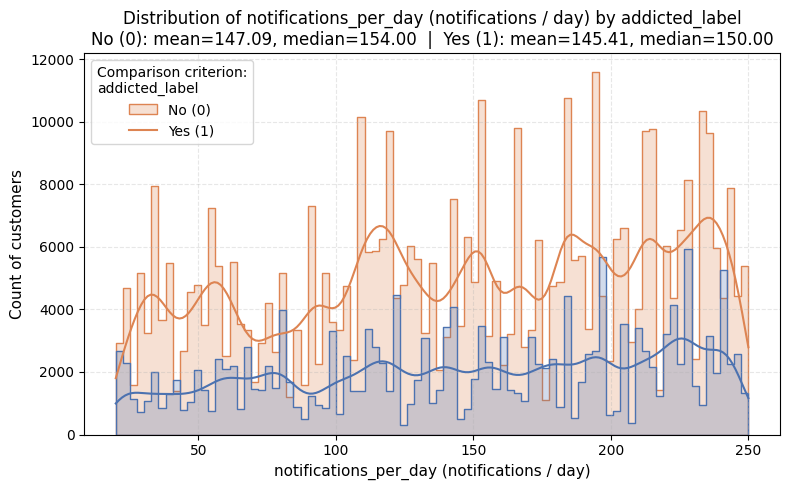

Saved: ./plots\hist_notifications_per_day_by_addicted_label.png


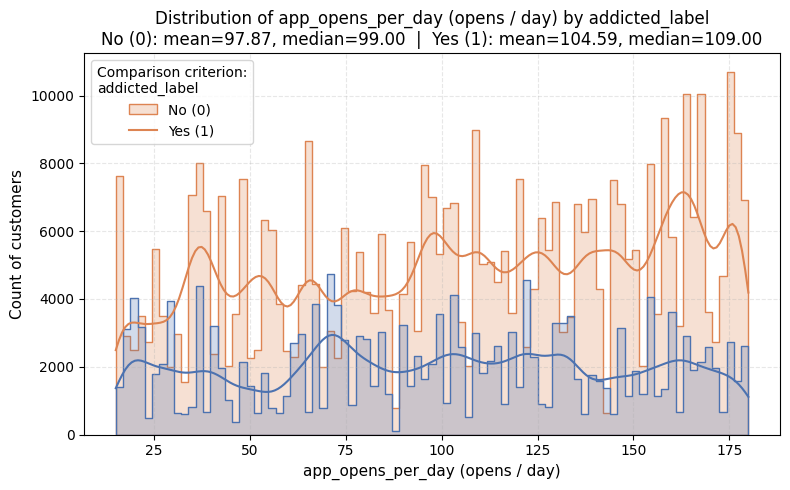

Saved: ./plots\hist_app_opens_per_day_by_addicted_label.png


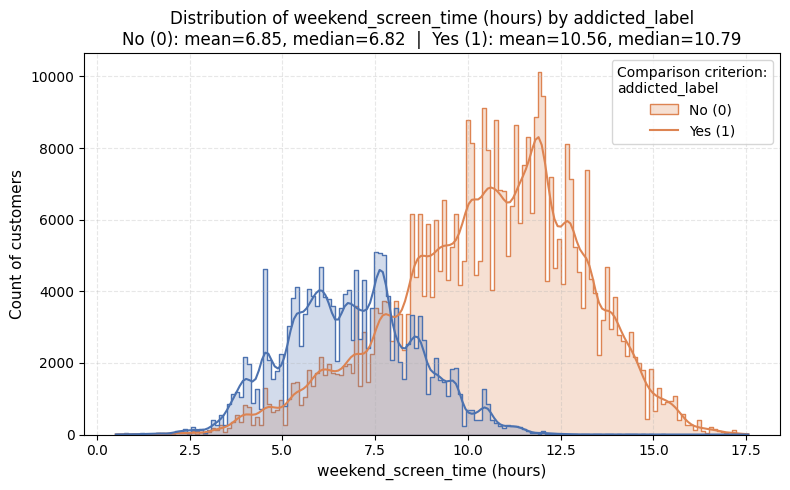

Saved: ./plots\hist_weekend_screen_time_by_addicted_label.png


In [ ]:
UNITS = {
    "age": "years",
    "daily_screen_time_hours": "hours",
    "social_media_hours": "hours",
    "gaming_hours": "hours",
    "work_study_hours": "hours",
    "sleep_hours": "hours",
    "notifications_per_day": "notifications / day",
    "app_opens_per_day": "opens / day",
    "weekend_screen_time": "hours",
}

# One plot per numeric feature
for c in num_cols:
    unit = UNITS.get(c, "")
    unit_str = f" ({unit})" if unit else ""

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=train,
        x=c,
        hue=TARGET,
        kde=True,
        element="step",
        stat="count",              
        common_norm=False,         
        palette={0: "#4C72B0", 1: "#DD8452"},
        ax=ax,
    )

    ax.set_xlabel(f"{c}{unit_str}", fontsize=11)
    ax.set_ylabel("Count of customers", fontsize=11)
    g = train.groupby(TARGET)[c]
    title_stats = "  |  ".join(
        f"{TARGET_LABELS[k]}: mean={g.mean()[k]:.2f}, median={g.median()[k]:.2f}"
        for k in sorted(g.mean().index)
    )
    ax.set_title(
        f"Distribution of {c}{unit_str} by {TARGET}\n{title_stats}",
        fontsize=12,
    )

    leg = ax.legend(
        title=f"Comparison criterion:\n{TARGET}",
        labels=[TARGET_LABELS[k] for k in sorted(TARGET_LABELS)],
        loc="best",
        frameon=True,
    )
    leg.get_title().set_fontsize(10)

    ax.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()

    # save with a descriptive file name 
    safe_name = c.replace(" ", "_").replace("/", "_")
    out_file = os.path.join(PLOT_PATH, f"hist_{safe_name}_by_{TARGET}.png")
    plt.savefig(out_file, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {out_file}")

# Categorical vs target (Addiction rate per category)

In [21]:
print("\n" + "=" * 70)
print("ADDICTION RATE BY CATEGORY")
print("=" * 70)
for c in cat_cols:
    rate = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    print(f"\n{c}:")
    print(rate)



ADDICTION RATE BY CATEGORY

gender:
gender
Male      0.723198
Female    0.703838
Other     0.701020
Name: addicted_label, dtype: float64

stress_level:
stress_level
High      0.711431
Low       0.711160
Medium    0.705663
Name: addicted_label, dtype: float64

academic_work_impact:
academic_work_impact
No     0.711029
Yes    0.707883
Name: addicted_label, dtype: float64


# Correlation matrix (numeric features + target)


CORRELATION WITH TARGET (numeric features)
daily_screen_time_hours    0.611398
weekend_screen_time        0.589903
social_media_hours         0.532409
work_study_hours           0.251416
gaming_hours               0.205283
app_opens_per_day          0.063482
sleep_hours                0.042545
notifications_per_day     -0.011583
age                        0.004043
Name: addicted_label, dtype: float64


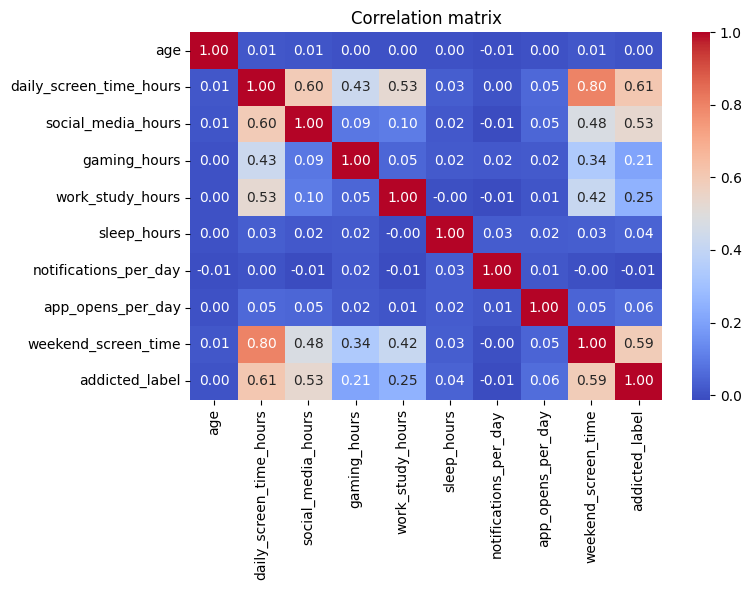

In [58]:
print("\n" + "=" * 70)
print("CORRELATION WITH TARGET (numeric features)")
print("=" * 70)
corr_with_target = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr_with_target)

plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/correlation_matrix.png")
plt.show()
plt.close()


# Outlier check (simple IQR based)

In [23]:
print("\n" + "=" * 70)
print("OUTLIER CHECK (IQR method)")
print("=" * 70)
for c in num_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((train[c] < lower) | (train[c] > upper)).sum()
    print(f"{c}: {n_outliers} potential outliers "
        f"(bounds: [{lower:.2f}, {upper:.2f}])")


OUTLIER CHECK (IQR method)
age: 0 potential outliers (bounds: [8.50, 44.50])
daily_screen_time_hours: 0 potential outliers (bounds: [-1.06, 16.38])
social_media_hours: 1209 potential outliers (bounds: [-1.43, 6.25])
gaming_hours: 0 potential outliers (bounds: [-1.39, 4.17])
work_study_hours: 300 potential outliers (bounds: [-1.40, 5.96])
sleep_hours: 0 potential outliers (bounds: [2.65, 11.00])
notifications_per_day: 0 potential outliers (bounds: [-73.50, 370.50])
app_opens_per_day: 0 potential outliers (bounds: [-57.50, 266.50])
weekend_screen_time: 6 potential outliers (bounds: [0.58, 18.45])


# FEATURE SUMMARY TABLE

In [24]:
rows = []
for c in num_cols:
    rows.append({
        "feature": c,
        "type": "numeric",
        "n_unique": train[c].nunique(),
        "min": train[c].min(),
        "max": train[c].max(),
        "mean": train[c].mean(),
        "std": train[c].std(),
        "skew": train[c].skew(),
        "kurtosis": train[c].kurtosis(),
        "missing": train[c].isna().sum(),
    })
for c in cat_cols:
    rows.append({
        "feature": c,
        "type": "categorical",
        "n_unique": train[c].nunique(),
        "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan,
        "skew": np.nan, "kurtosis": np.nan,
        "missing": train[c].isna().sum(),
    })

summary = pd.DataFrame(rows).sort_values("feature").reset_index(drop=True)
print(summary.to_string(index=False))
summary.to_csv(f"{PLOT_PATH}/feature_summary.csv", index=False)

                feature        type  n_unique   min    max       mean       std      skew  kurtosis  missing
   academic_work_impact categorical         2   NaN    NaN        NaN       NaN       NaN       NaN    44224
                    age     numeric        18 18.00  35.00  26.615408  5.153162 -0.036801 -1.217351    28929
      app_opens_per_day     numeric       166 15.00 180.00 102.636781 48.093970 -0.126463 -1.166561    80710
daily_screen_time_hours     numeric      1389  0.50  15.00   7.640865  2.721446 -0.131972 -0.921224    95854
           gaming_hours     numeric       401  0.00   4.00   1.459265  0.934552  0.544740 -0.457057   126821
                 gender categorical         3   NaN    NaN        NaN       NaN       NaN       NaN    29034
  notifications_per_day     numeric       231 20.00 250.00 145.894900 65.917556 -0.206535 -1.129833    67584
            sleep_hours     numeric       451  4.50   9.00   6.804334  1.234512 -0.006587 -1.128223    44480
     social_media_h

# TARGET RATE BY BINNED NUMERIC FEATURE

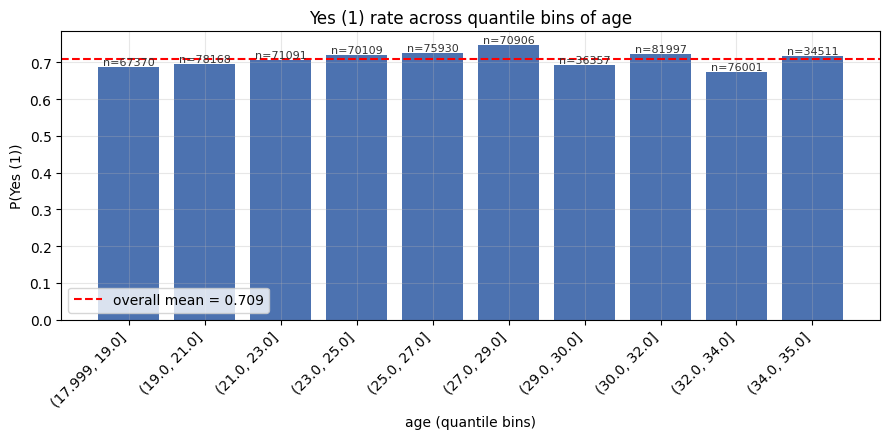


age:
                  rate  count
bin                          
(17.999, 19.0]  0.6883  67370
(19.0, 21.0]    0.6964  78168
(21.0, 23.0]    0.7052  71091
(23.0, 25.0]    0.7192  70109
(25.0, 27.0]    0.7264  75930
(27.0, 29.0]    0.7470  70906
(29.0, 30.0]    0.6914  36357
(30.0, 32.0]    0.7231  81997
(32.0, 34.0]    0.6731  76001
(34.0, 35.0]    0.7173  34511


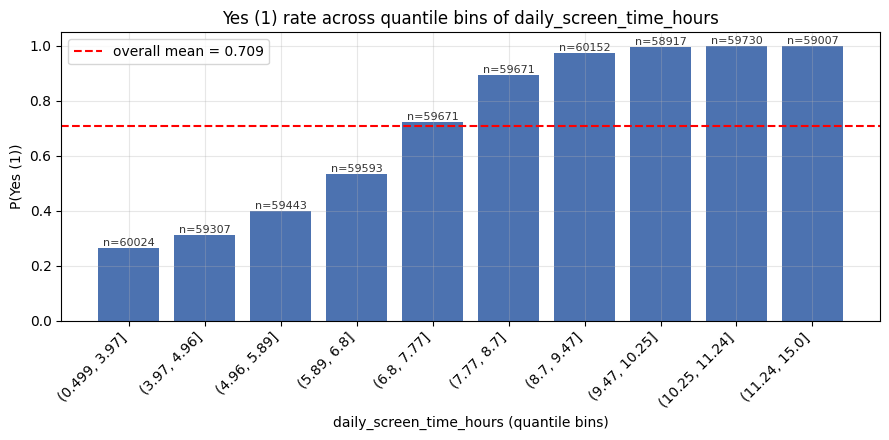


daily_screen_time_hours:
                  rate  count
bin                          
(0.499, 3.97]   0.2651  60024
(3.97, 4.96]    0.3104  59307
(4.96, 5.89]    0.3986  59443
(5.89, 6.8]     0.5343  59593
(6.8, 7.77]     0.7234  59671
(7.77, 8.7]     0.8953  59671
(8.7, 9.47]     0.9743  60152
(9.47, 10.25]   0.9947  58917
(10.25, 11.24]  0.9987  59730
(11.24, 15.0]   0.9997  59007


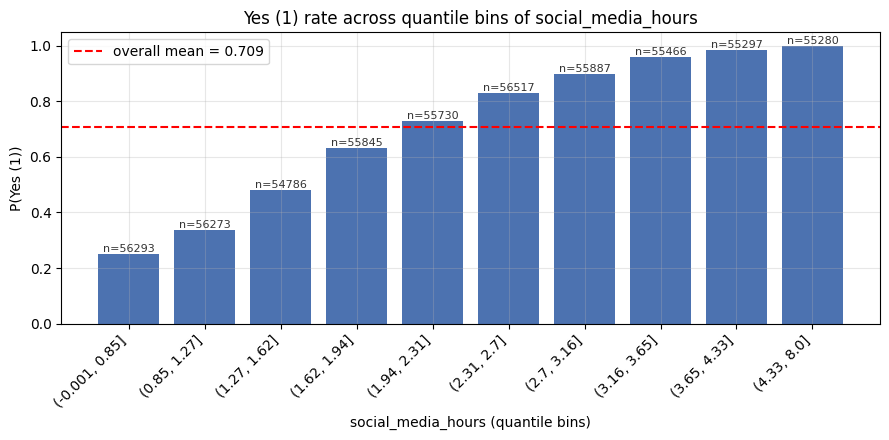


social_media_hours:
                  rate  count
bin                          
(-0.001, 0.85]  0.2496  56293
(0.85, 1.27]    0.3378  56273
(1.27, 1.62]    0.4794  54786
(1.62, 1.94]    0.6319  55845
(1.94, 2.31]    0.7287  55730
(2.31, 2.7]     0.8311  56517
(2.7, 3.16]     0.8998  55887
(3.16, 3.65]    0.9597  55466
(3.65, 4.33]    0.9855  55297
(4.33, 8.0]     0.9986  55280


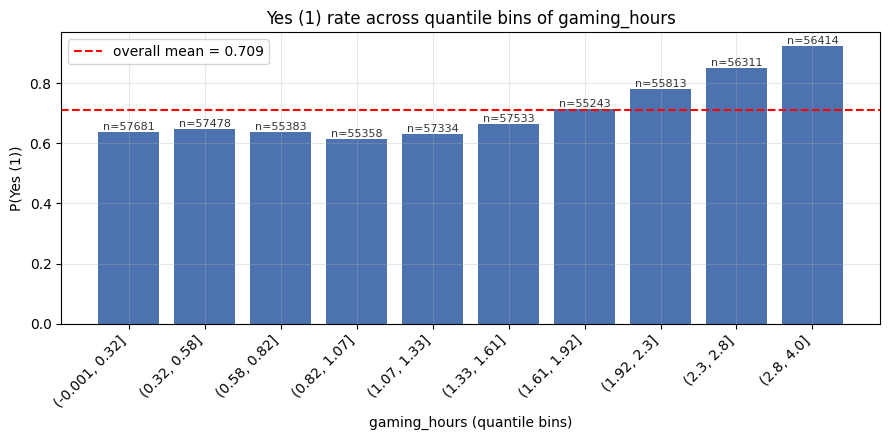


gaming_hours:
                  rate  count
bin                          
(-0.001, 0.32]  0.6384  57681
(0.32, 0.58]    0.6477  57478
(0.58, 0.82]    0.6376  55383
(0.82, 1.07]    0.6131  55358
(1.07, 1.33]    0.6303  57334
(1.33, 1.61]    0.6627  57533
(1.61, 1.92]    0.7135  55243
(1.92, 2.3]     0.7799  55813
(2.3, 2.8]      0.8492  56311
(2.8, 4.0]      0.9224  56414


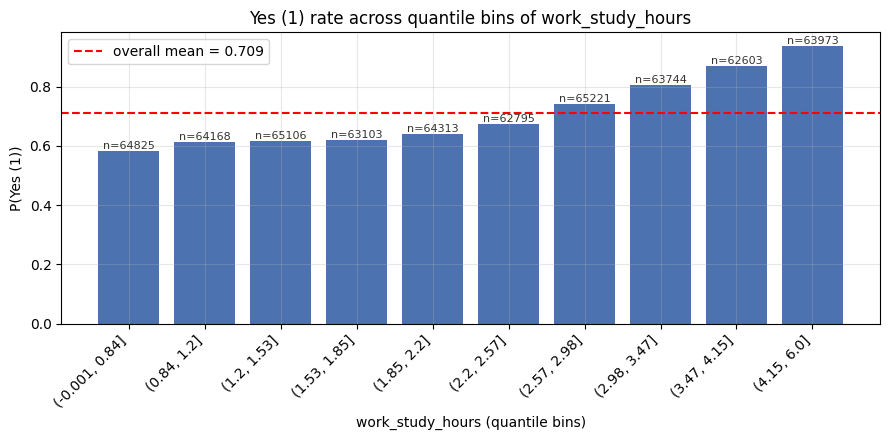


work_study_hours:
                  rate  count
bin                          
(-0.001, 0.84]  0.5811  64825
(0.84, 1.2]     0.6144  64168
(1.2, 1.53]     0.6171  65106
(1.53, 1.85]    0.6214  63103
(1.85, 2.2]     0.6397  64313
(2.2, 2.57]     0.6731  62795
(2.57, 2.98]    0.7419  65221
(2.98, 3.47]    0.8054  63744
(3.47, 4.15]    0.8680  62603
(4.15, 6.0]     0.9364  63973


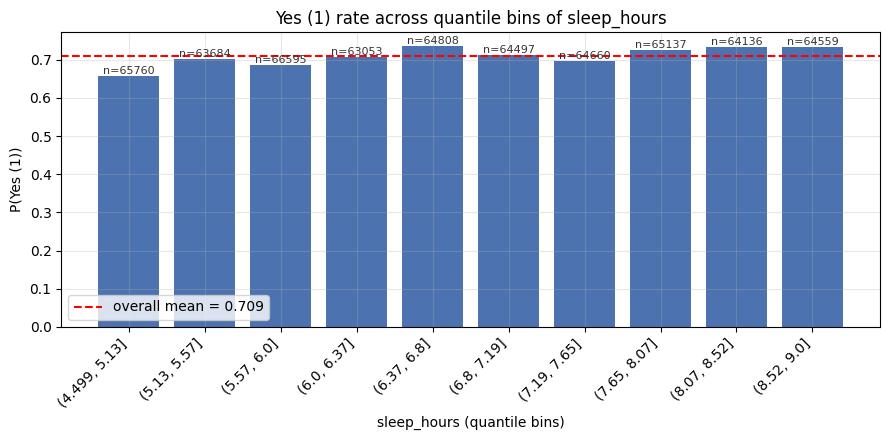


sleep_hours:
                 rate  count
bin                         
(4.499, 5.13]  0.6571  65760
(5.13, 5.57]   0.7027  63684
(5.57, 6.0]    0.6858  66595
(6.0, 6.37]    0.7085  63053
(6.37, 6.8]    0.7352  64808
(6.8, 7.19]    0.7127  64497
(7.19, 7.65]   0.6959  64660
(7.65, 8.07]   0.7267  65137
(8.07, 8.52]   0.7342  64136
(8.52, 9.0]    0.7342  64559


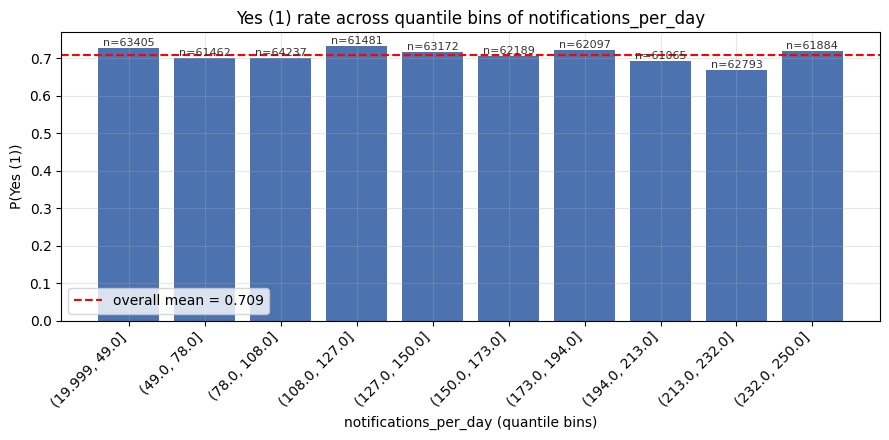


notifications_per_day:
                  rate  count
bin                          
(19.999, 49.0]  0.7268  63405
(49.0, 78.0]    0.7017  61462
(78.0, 108.0]   0.7012  64237
(108.0, 127.0]  0.7329  61481
(127.0, 150.0]  0.7166  63172
(150.0, 173.0]  0.7070  62189
(173.0, 194.0]  0.7231  62097
(194.0, 213.0]  0.6934  61065
(213.0, 232.0]  0.6699  62793
(232.0, 250.0]  0.7208  61884


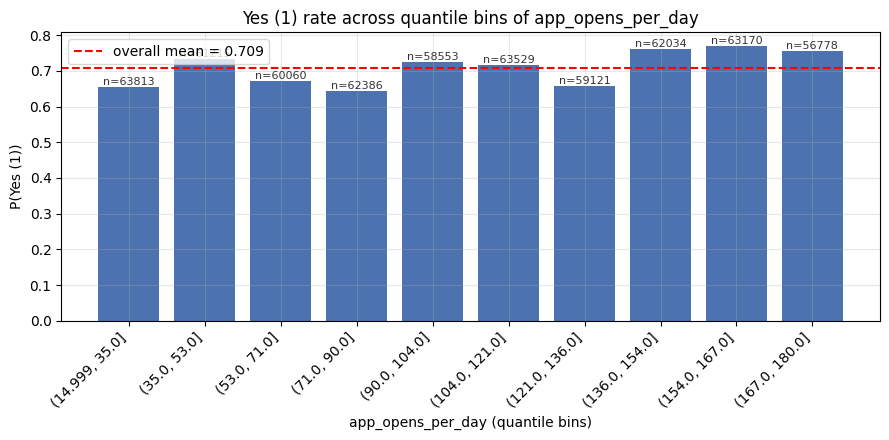


app_opens_per_day:
                  rate  count
bin                          
(14.999, 35.0]  0.6546  63813
(35.0, 53.0]    0.7340  61215
(53.0, 71.0]    0.6730  60060
(71.0, 90.0]    0.6445  62386
(90.0, 104.0]   0.7256  58553
(104.0, 121.0]  0.7162  63529
(121.0, 136.0]  0.6570  59121
(136.0, 154.0]  0.7626  62034
(154.0, 167.0]  0.7697  63170
(167.0, 180.0]  0.7547  56778


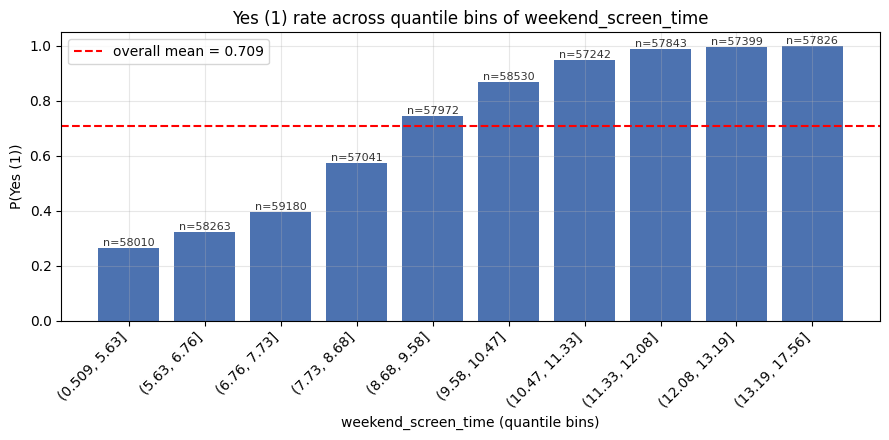


weekend_screen_time:
                  rate  count
bin                          
(0.509, 5.63]   0.2644  58010
(5.63, 6.76]    0.3221  58263
(6.76, 7.73]    0.3962  59180
(7.73, 8.68]    0.5728  57041
(8.68, 9.58]    0.7464  57972
(9.58, 10.47]   0.8680  58530
(10.47, 11.33]  0.9485  57242
(11.33, 12.08]  0.9881  57843
(12.08, 13.19]  0.9980  57399
(13.19, 17.56]  0.9997  57826

Trend summary (first bin → last bin):
                         age  0.688 → 0.717  ↑
     daily_screen_time_hours  0.265 → 1.000  ↑
          social_media_hours  0.250 → 0.999  ↑
                gaming_hours  0.638 → 0.922  ↑
            work_study_hours  0.581 → 0.936  ↑
                 sleep_hours  0.657 → 0.734  ↑
       notifications_per_day  0.727 → 0.721  ↓
           app_opens_per_day  0.655 → 0.755  ↑
         weekend_screen_time  0.264 → 1.000  ↑


In [57]:
N_BINS = 10
bin_rate_tables = {}
overall = train[TARGET].mean()

for c in num_cols:
    tmp = train[[c, TARGET]].dropna(subset=[c]).copy()
    try:
        tmp["bin"] = pd.qcut(tmp[c], q=N_BINS, duplicates="drop")
        binned_by = "quantile"
    except (ValueError, TypeError):
        tmp["bin"] = pd.cut(tmp[c], bins=N_BINS)
        binned_by = "equal-width"

    g = (
        tmp.groupby("bin", observed=True)[TARGET]
        .agg(rate="mean", count="count")
    )
    bin_rate_tables[c] = g

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(g))
    bars = ax.bar(x, g["rate"], color="#4C72B0")
    ax.axhline(overall, color="red", ls="--",
               label=f"overall mean = {overall:.3f}")

    for b, cnt in zip(bars, g["count"]):
        ax.annotate(f"n={cnt}", (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=8, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in g.index], rotation=45, ha="right")
    ax.set_xlabel(f"{c} ({binned_by} bins)")
    ax.set_ylabel(f"P({TARGET_LABELS[1]})")
    ax.set_title(f"{TARGET_LABELS[1]} rate across {binned_by} bins of {c}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/rate_bins_{c}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n{c}:")
    print(g.round(4).to_string())

# trend summary
print("\nTrend summary (first bin → last bin):")
for c, g in bin_rate_tables.items():
    r = g["rate"].values
    arrow = "↑" if r[-1] > r[0] else ("↓" if r[-1] < r[0] else "≈")
    print(f"{c:>28s}  {r[0]:.3f} → {r[-1]:.3f}  {arrow}")

# CATEGORICAL ADDICTION RATE WITH 95% CI

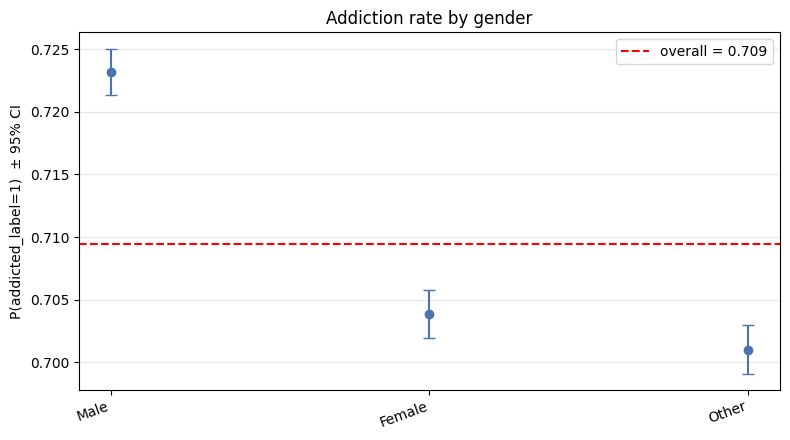


gender:
          mean   count      se   ci_lo   ci_hi
gender                                        
Male    0.7232  223662  0.0009  0.7213  0.7251
Female  0.7038  221595  0.0010  0.7019  0.7057
Other   0.7010  217078  0.0010  0.6991  0.7029


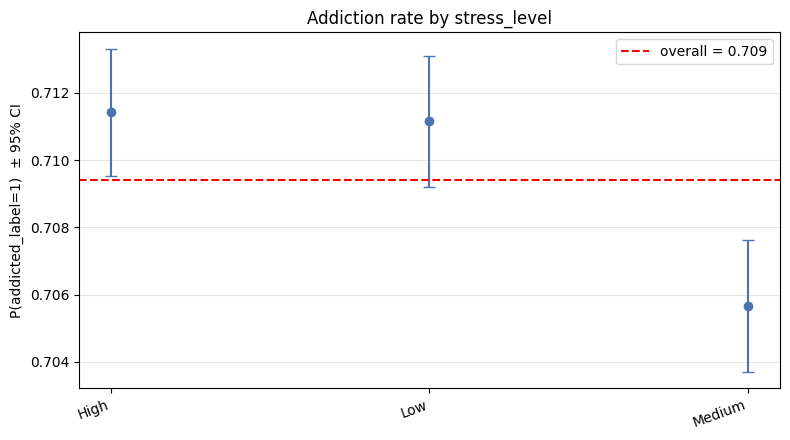


stress_level:
                mean   count     se   ci_lo   ci_hi
stress_level                                       
High          0.7114  220873  0.001  0.7095  0.7133
Low           0.7112  207783  0.001  0.7092  0.7131
Medium        0.7057  207565  0.001  0.7037  0.7076


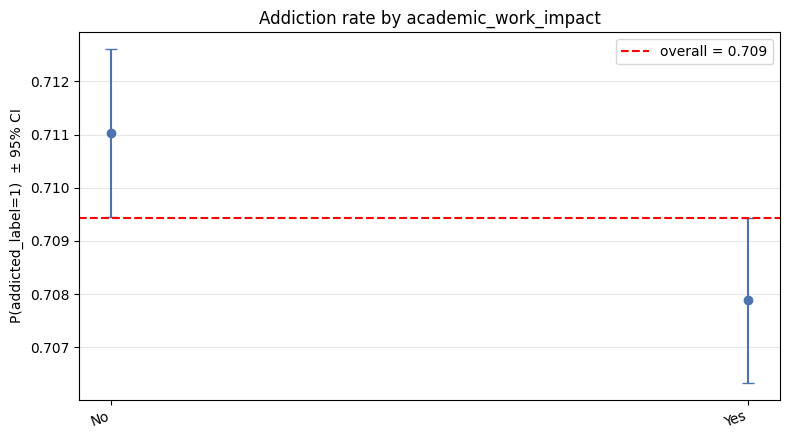


academic_work_impact:
                        mean   count      se   ci_lo   ci_hi
academic_work_impact                                        
No                    0.7110  316579  0.0008  0.7095  0.7126
Yes                   0.7079  330566  0.0008  0.7063  0.7094


In [56]:
overall = train[TARGET].mean()
cat_rate_tables = {}

for c in cat_cols:
    g = train.groupby(c)[TARGET].agg(["mean", "count"])
    g["se"] = np.sqrt(g["mean"] * (1 - g["mean"]) / g["count"])
    g["ci_lo"] = g["mean"] - 1.96 * g["se"]
    g["ci_hi"] = g["mean"] + 1.96 * g["se"]
    g = g.sort_values("mean", ascending=False)
    cat_rate_tables[c] = g

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(g))
    ax.errorbar(x, g["mean"], yerr=1.96 * g["se"],
                fmt="o", capsize=4, color="#4C72B0")
    ax.axhline(overall, color="red", ls="--",
               label=f"overall = {overall:.3f}")
    ax.set_xticks(x)
    ax.set_xticklabels(g.index, rotation=20, ha="right")
    ax.set_ylabel(f"P({TARGET}=1)  ± 95% CI")
    ax.set_title(f"Addiction rate by {c}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/addiction_rate_cat_{c}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n{c}:")
    print(g.round(4))

# CHI-SQUARE TEST OF INDEPENDENCE

In [27]:
from scipy.stats import chi2_contingency

chi_rows = []
for c in cat_cols:
    ct = pd.crosstab(train[c], train[TARGET])
    chi2, p, dof, expected = chi2_contingency(ct)
    # Cramér's V as effect size (0 = no assoc, 1 = perfect)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi_rows.append({
        "feature": c,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cramers_v,
    })

chi_df = pd.DataFrame(chi_rows).sort_values("cramers_v", ascending=False)
print(chi_df.to_string(index=False))
chi_df.to_csv(f"{PLOT_PATH}/chi_square_results.csv", index=False)

             feature       chi2      p_value  dof  cramers_v
              gender 313.792691 7.257432e-69    2   0.021766
        stress_level  21.594281 2.045792e-05    2   0.005826
academic_work_impact   7.751918 5.365552e-03    1   0.003461


# MUTUAL INFORMATION WITH TARGET

daily_screen_time_hours          0.22413
weekend_screen_time              0.20651
social_media_hours               0.16033
notifications_per_day            0.08660
app_opens_per_day                0.07886
work_study_hours                 0.04194
gaming_hours                     0.02966
sleep_hours                      0.01258
social_media_hours__isna         0.01044
gaming_hours__isna               0.00978
age                              0.00913
weekend_screen_time__isna        0.00685
daily_screen_time_hours__isna    0.00525
app_opens_per_day__isna          0.00308
notifications_per_day__isna      0.00265
sleep_hours__isna                0.00229
age__isna                        0.00098
gender                           0.00023
stress_level                     0.00002
academic_work_impact             0.00001
work_study_hours__isna           0.00000


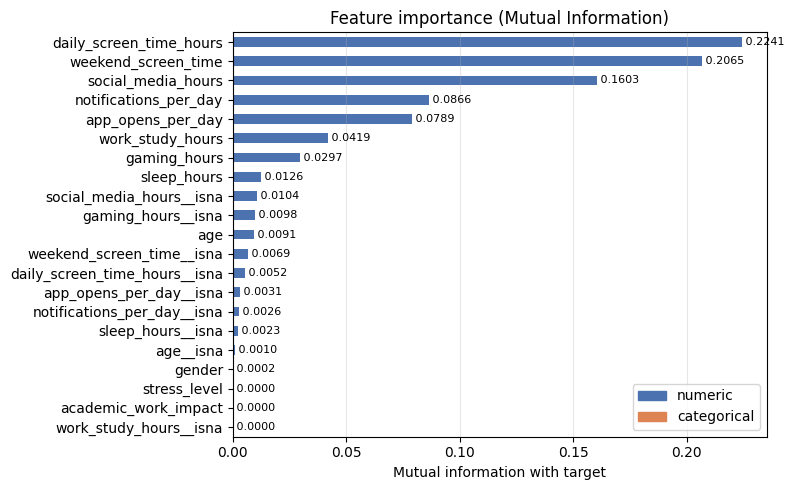

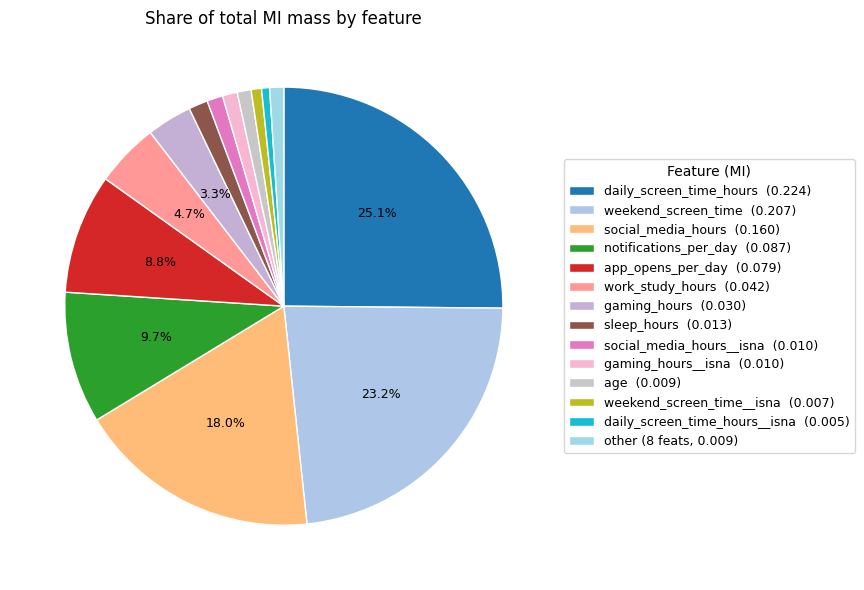

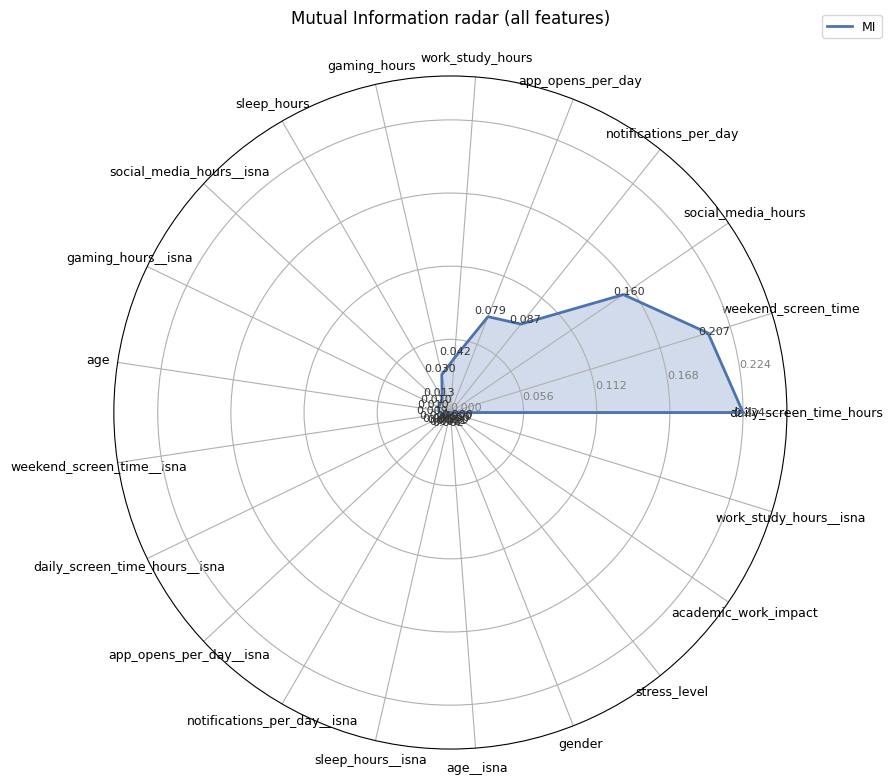

In [55]:
from sklearn.feature_selection import mutual_info_classif

#  MI computation 
X_all = train[num_cols + cat_cols].copy()

for c in num_cols:
    if X_all[c].isna().any():
        X_all[f"{c}__isna"] = X_all[c].isna().astype(int)
        X_all[c] = X_all[c].fillna(X_all[c].median())

for c in cat_cols:
    X_all[c] = X_all[c].fillna("__MISSING__").astype("category").cat.codes

discrete_mask = [c in cat_cols for c in X_all.columns]

y = train[TARGET].values
assert not pd.isna(y).any(), "Target has NaN"

mi = mutual_info_classif(
    X_all, y,
    discrete_features=discrete_mask,
    random_state=42,
)
mi_series = pd.Series(mi, index=X_all.columns).sort_values(ascending=False)
print(mi_series.round(5).to_string())

# BAR CHART (your existing one)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#DD8452" if c in cat_cols else "#4C72B0" for c in mi_series.index]
mi_series.plot.barh(ax=ax, color=colors)
ax.invert_yaxis()

for i, v in enumerate(mi_series.values):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=8)

ax.set_xlabel("Mutual information with target")
ax.set_title("Feature importance (Mutual Information)")
ax.grid(alpha=0.3, axis="x")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#4C72B0", label="numeric"),
    Patch(color="#DD8452", label="categorical"),
], loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_bar.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

# PIE CHART — share of total MI mass
THRESHOLD = mi_series.sum() * 0.005                                 # features < 0.5% of total → "other"
big   = mi_series[mi_series >= THRESHOLD]
small = mi_series[mi_series <  THRESHOLD]

pie_vals = list(big.values)
pie_lbls = [f"{n}  ({v:.3f})" for n, v in big.items()]
if len(small) > 0:
    pie_vals.append(small.sum())
    pie_lbls.append(f"other ({len(small)} feats, {small.sum():.3f})")

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(pie_vals)))
wedges, _, autotexts = ax.pie(
    pie_vals,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
    startangle=90, counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)
ax.legend(wedges, pie_lbls, title="Feature (MI)",
          loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.set_title("Share of total MI mass by feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# RADAR CHART — MI profile across features
labels = mi_series.index.tolist()
vals   = mi_series.values
n = len(labels)

angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]
vals_plot = vals.tolist() + [vals[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, vals_plot, color="#4C72B0", linewidth=2, label="MI")
ax.fill(angles, vals_plot, color="#4C72B0", alpha=0.25)

# annotate each vertex
for ang, v in zip(angles[:-1], vals):
    ax.text(ang, v + 0.005, f"{v:.3f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, max(vals)*1.15)
ax.set_yticks(np.linspace(0, max(vals), 5))
ax.set_yticklabels([f"{v:.3f}" for v in np.linspace(0, max(vals), 5)],
                   fontsize=8, color="gray")
ax.set_rlabel_position(180 / n)
ax.set_title("Mutual Information radar (all features)", fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_radar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# FEATURE-FEATURE CORRELATION (numeric only) + VIF

Top correlated numeric pairs:
                                               corr
daily_screen_time_hours weekend_screen_time  0.8001
                        social_media_hours   0.5956
                        work_study_hours     0.5259
social_media_hours      weekend_screen_time  0.4781
daily_screen_time_hours gaming_hours         0.4293
work_study_hours        weekend_screen_time  0.4175
gaming_hours            weekend_screen_time  0.3421
social_media_hours      work_study_hours     0.1005
                        gaming_hours         0.0882
daily_screen_time_hours app_opens_per_day    0.0549
gaming_hours            work_study_hours     0.0490
social_media_hours      app_opens_per_day    0.0478
app_opens_per_day       weekend_screen_time  0.0463
sleep_hours             weekend_screen_time  0.0283
daily_screen_time_hours sleep_hours          0.0282

VIF:
daily_screen_time_hours    3.002
weekend_screen_time        2.047
social_media_hours         1.501
work_study_hours           1.419


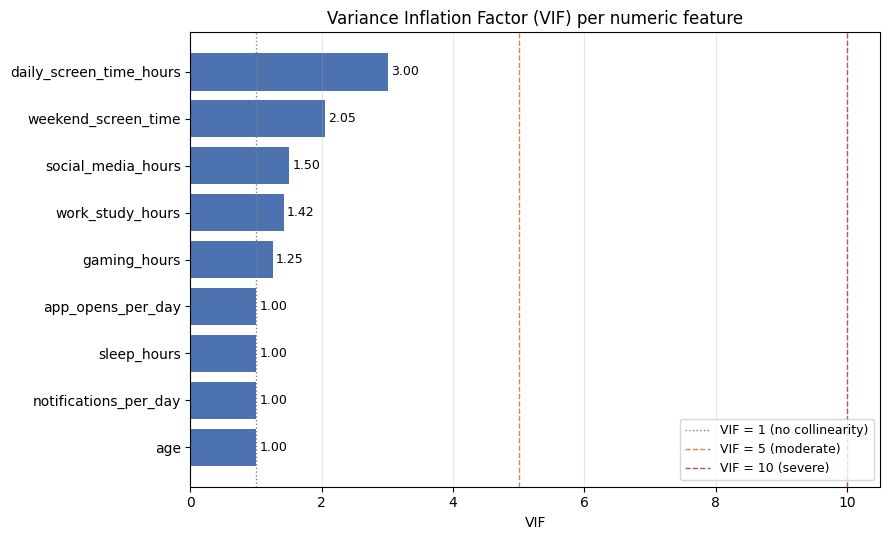

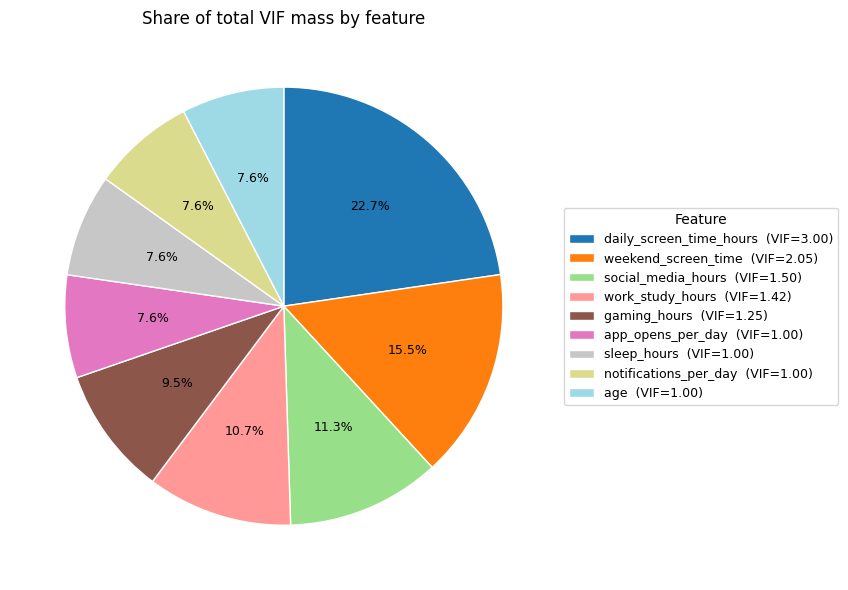

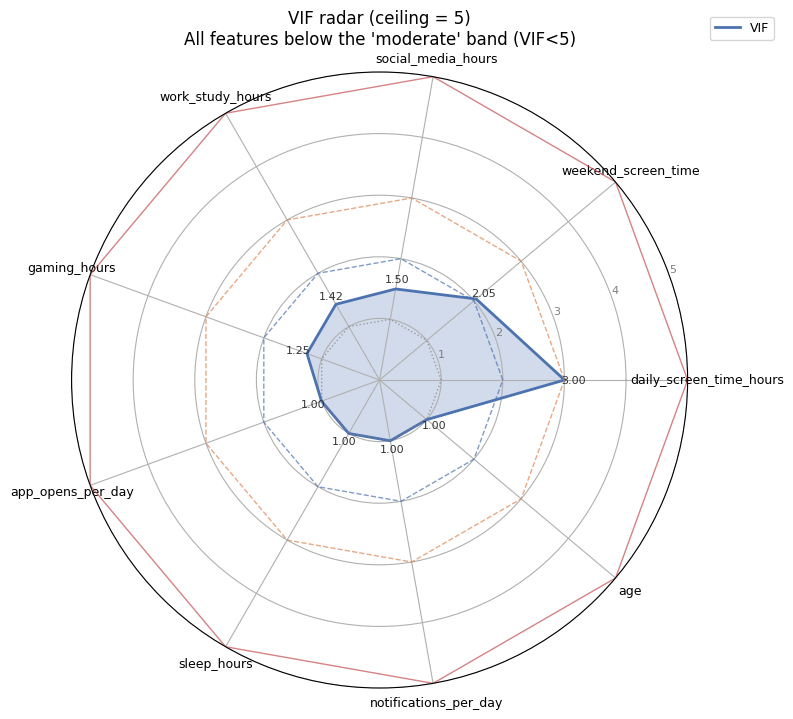

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Correlation (unchanged, cleaned up) 
corr = train[num_cols].corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (
    corr.where(mask)
         .stack()
         .rename("corr")
         .to_frame()
         .assign(abs_corr=lambda d: d["corr"].abs())
         .sort_values("abs_corr", ascending=False)
         .drop(columns="abs_corr")
)
print("Top correlated numeric pairs:")
print(pairs.head(15).round(4).to_string())

# VIF (unchanged, NaN-safe) 
sample = train[num_cols].sample(min(50_000, len(train)), random_state=42).copy()
sample = sample.fillna(sample.median(numeric_only=True))
sample = sample.replace([np.inf, -np.inf], np.nan).dropna()

X_vif = add_constant(sample, has_constant="add")
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const").sort_values(ascending=False)

print("\nVIF:")
print(vif.round(3).to_string())

#  BAR CHART — VIF per feature with severity bands
def vif_color(v):
    if v < 5:   return "#4C72B0"   # fine
    if v < 10:  return "#DD8452"   # watch
    return "#C44E52"               # problem

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(vif.index, vif.values, color=[vif_color(v) for v in vif.values])
ax.invert_yaxis()

# reference lines
ax.axvline(1,  color="gray",    ls=":",  lw=1, label="VIF = 1 (no collinearity)")
ax.axvline(5,  color="#DD8452", ls="--", lw=1, label="VIF = 5 (moderate)")
ax.axvline(10, color="#C44E52", ls="--", lw=1, label="VIF = 10 (severe)")

# value labels
for b, v in zip(bars, vif.values):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2,
            f"{v:.2f}", va="center", fontsize=9)

ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor (VIF) per numeric feature")
ax.grid(alpha=0.3, axis="x")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_bar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

#  PIE CHART — share of total VIF mass per feature(shows which features dominate the collinearity "budget")
vif_pos = vif.clip(lower=0)                                 # VIF is always >= 1 in practice, but guard anyway

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(vif_pos)))
wedges, _, autotexts = ax.pie(
    vif_pos.values,
    labels=None,                                            # use legend instead to avoid crowding
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",        # hide tiny slices
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)
ax.legend(
    wedges,
    [f"{name}  (VIF={val:.2f})" for name, val in zip(vif_pos.index, vif_pos.values)],
    title="Feature",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
)
ax.set_title("Share of total VIF mass by feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# Use ceiling=5 so the 1-3 range spreads visibly; cap anything above at 5.
CEIL = 5.0

labels = vif.index.tolist()
values = np.clip(vif.values, 0, CEIL)
n = len(labels)

# angles: close the loop by repeating first point
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]
values_plot = values.tolist() + [values[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# main polygon 
ax.plot(angles, values_plot, color="#4C72B0", linewidth=2, label="VIF")
ax.fill(angles, values_plot, color="#4C72B0", alpha=0.25)

# reference rings for severity 
for ref, color, style in [(1, "gray", ":"), (2, "#4C72B0", "--"),
                          (3, "#DD8452", "--"), (5, "#C44E52", "-")]:
    if ref <= CEIL:
        ax.plot(angles, [ref] * (n + 1), color=color, ls=style,
                lw=1, alpha=0.7)

# tick labels at each feature 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)

# radial grid 
ax.set_ylim(0, CEIL)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=8, color="gray")
ax.set_rlabel_position(180 / n)  # move radial labels off the first axis

# annotate each vertex with the true VIF value 
for ang, v, true_v in zip(angles[:-1], values, vif.values):
    ax.text(ang, v + 0.15, f"{true_v:.2f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_title("VIF radar (ceiling = 5)\nAll features below the 'moderate' band (VIF<5)",
             fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_radar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# NUMERIC x CATEGORICAL INTERACTIONS

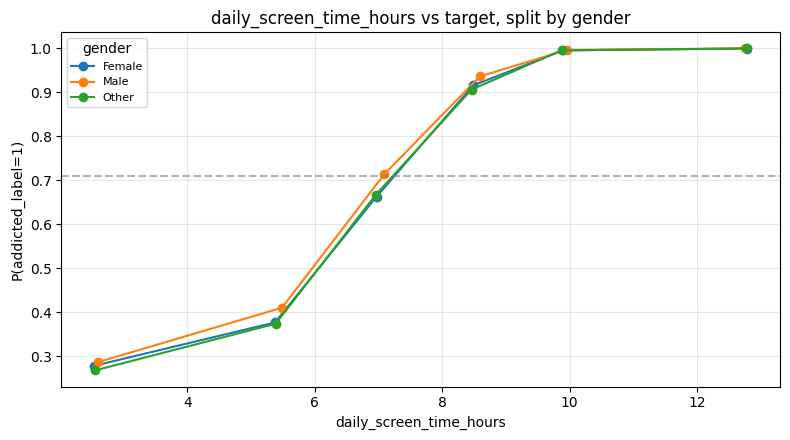

Saved ./plots/interaction_daily_screen_time_hours_x_gender.png


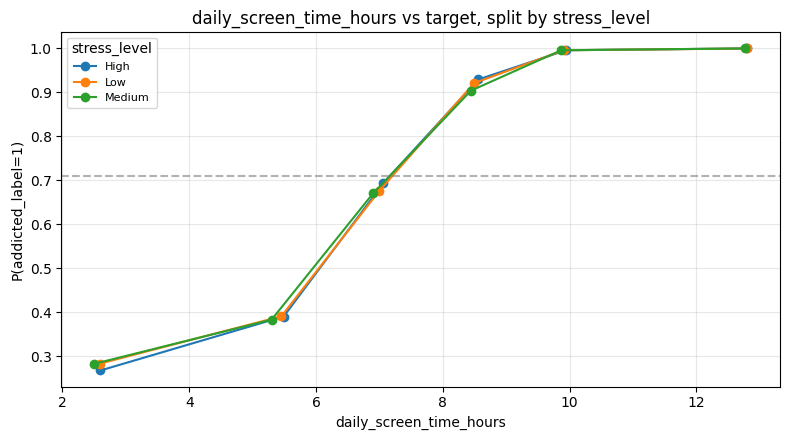

Saved ./plots/interaction_daily_screen_time_hours_x_stress_level.png


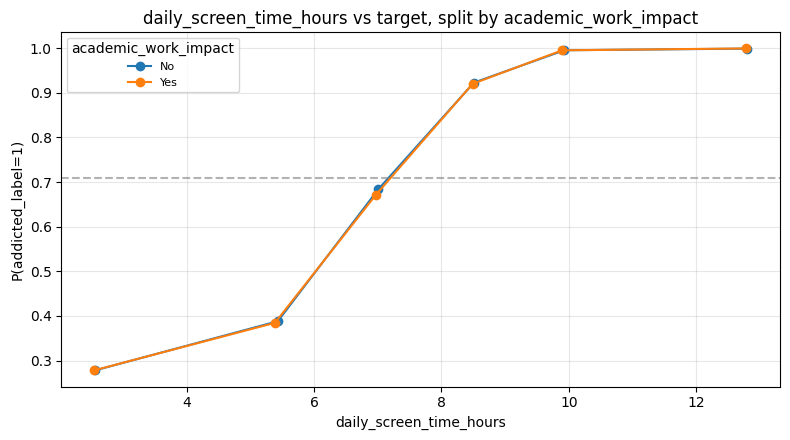

Saved ./plots/interaction_daily_screen_time_hours_x_academic_work_impact.png


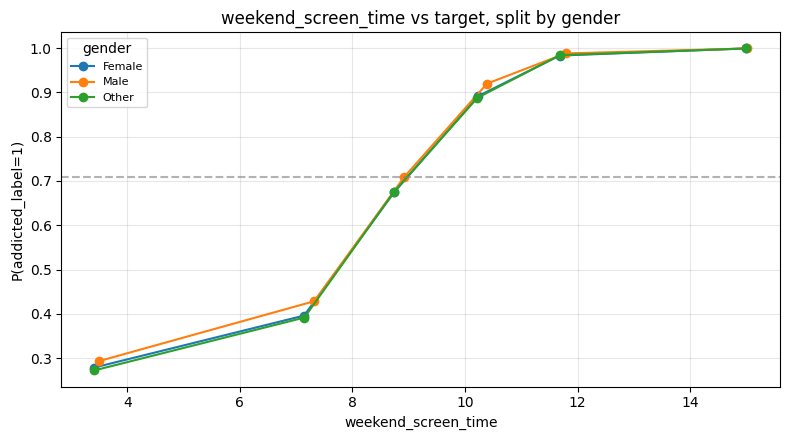

Saved ./plots/interaction_weekend_screen_time_x_gender.png


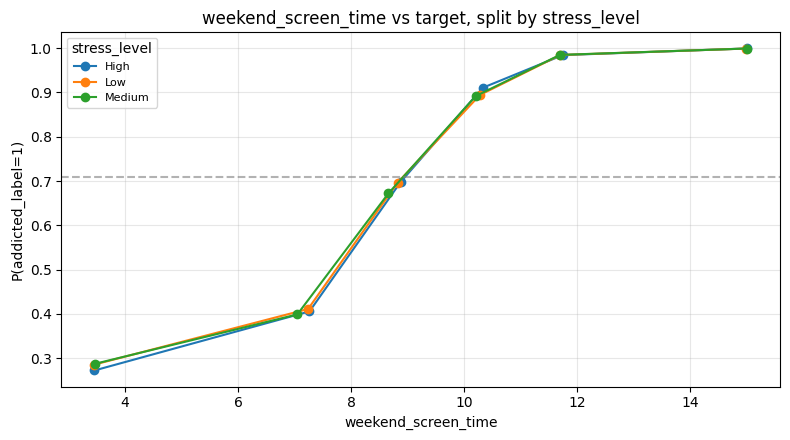

Saved ./plots/interaction_weekend_screen_time_x_stress_level.png


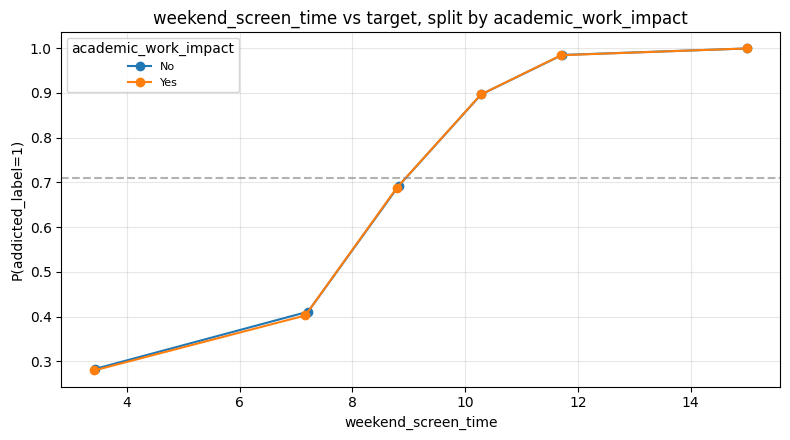

Saved ./plots/interaction_weekend_screen_time_x_academic_work_impact.png


In [50]:
# Pick the strongest numeric feature (from MI / Pearson) and check whether its relationship with the target changes across categories.
strong_numeric = mi_series.head(2).index.tolist()
strong_numeric = [c for c in strong_numeric if c in num_cols]

for num_c in strong_numeric:
    for cat_c in cat_cols:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for cat_val, sub in train.groupby(cat_c):
            # bin numeric, compute rate within this category
            try:
                binned = pd.qcut(sub[num_c], q=6, duplicates="drop")
            except ValueError:
                continue
            rate = sub.groupby(binned, observed=True)[TARGET].mean()
            mids = [iv.mid for iv in rate.index]
            ax.plot(mids, rate.values, marker="o", label=str(cat_val))
        ax.axhline(train[TARGET].mean(), color="grey", ls="--", alpha=0.6)
        ax.set_xlabel(num_c)
        ax.set_ylabel(f"P({TARGET}=1)")
        ax.set_title(f"{num_c} vs target, split by {cat_c}")
        ax.legend(title=cat_c, fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        fname = f"{PLOT_PATH}/interaction_{num_c}_x_{cat_c}.png"
        plt.savefig(fname, dpi=110, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved {fname}")

# PAIRPLOT OF TOP FEATURES

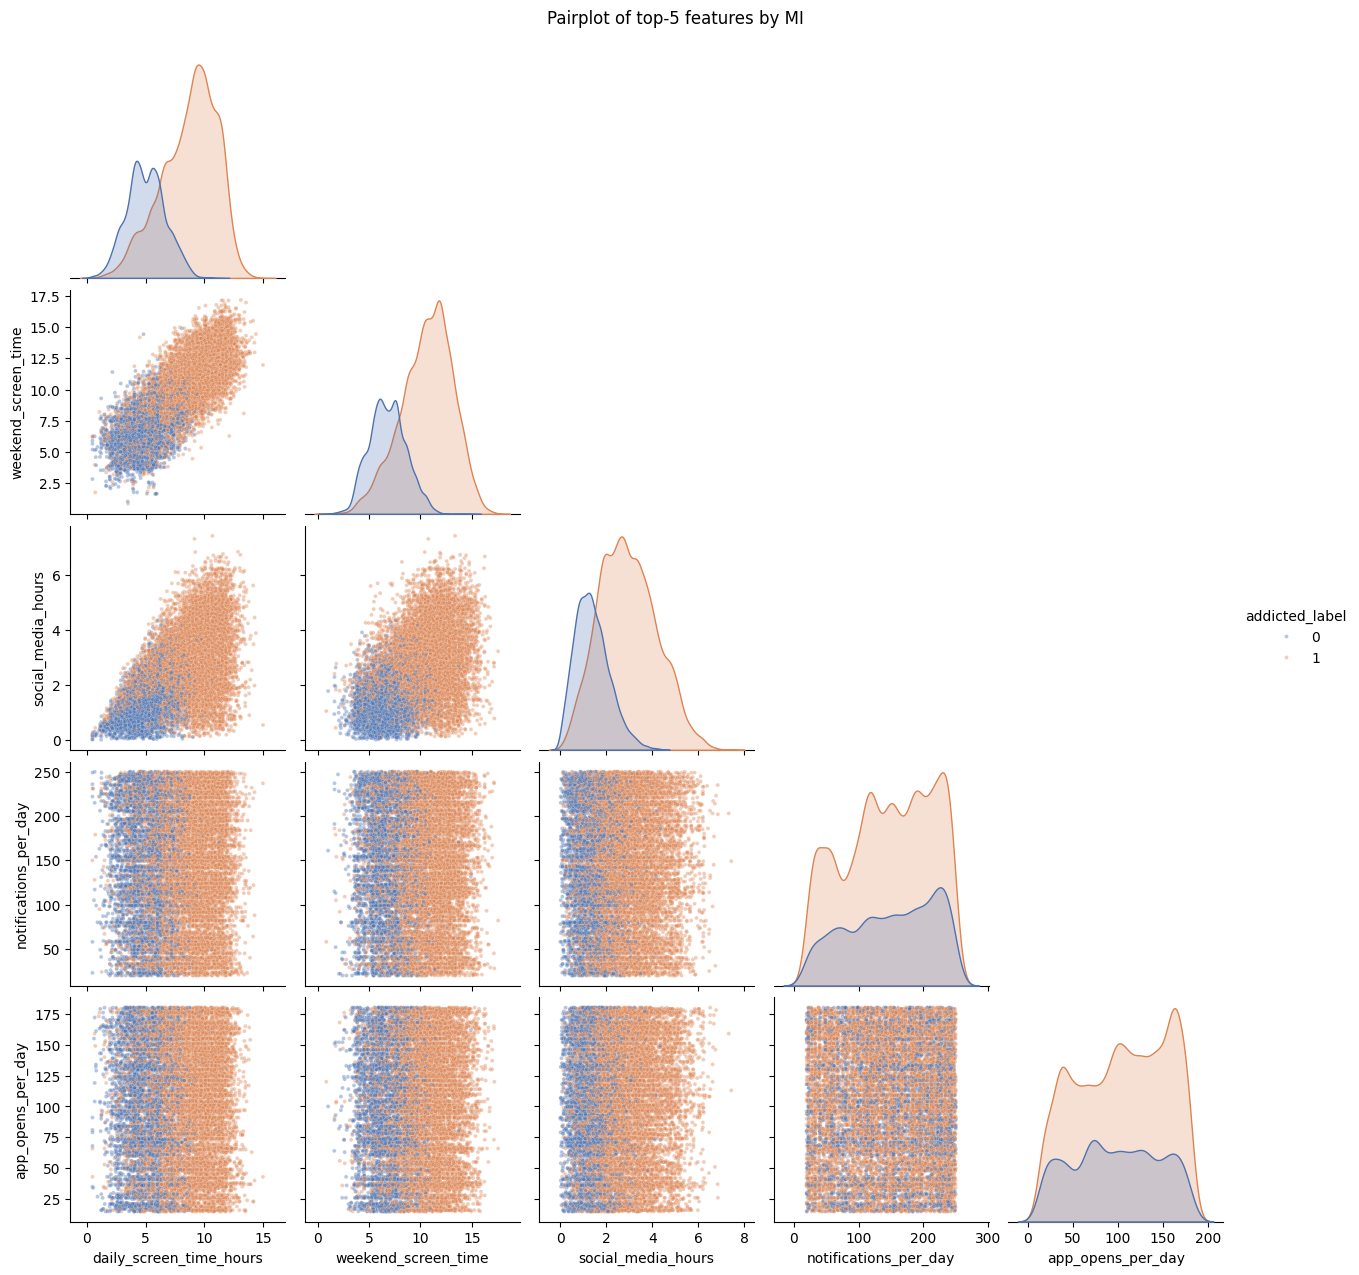

In [49]:
PALETTE = {0: "#4C72B0", 1: "#DD8452"}

top_feats = mi_series.head(5).index.tolist()
sample = train.sample(min(20000, len(train)), random_state=42)

g = sns.pairplot(
    sample[top_feats + [TARGET]],
    hue=TARGET,
    palette=PALETTE,
    corner=True,
    plot_kws={"s": 8, "alpha": 0.4},
    diag_kind="kde",
)
g.fig.suptitle("Pairplot of top-5 features by MI", y=1.02)
g.savefig(f"{PLOT_PATH}/pairplot_top_features.png", dpi=110, bbox_inches="tight")
plt.show()
plt.close()

# ADDICTION RATE PER SEGMENT (2-way)


gender x stress_level: Addiction rate
stress_level   High    Low  Medium
gender                            
Female        0.705  0.707   0.698
Male          0.726  0.725   0.719
Other         0.703  0.700   0.700


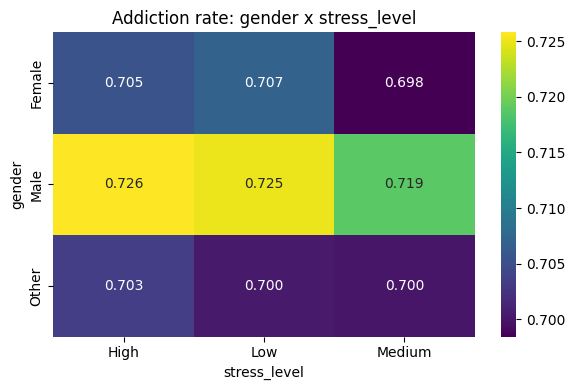


gender x academic_work_impact: Addiction rate
academic_work_impact     No    Yes
gender                            
Female                0.705  0.702
Male                  0.724  0.722
Other                 0.703  0.699


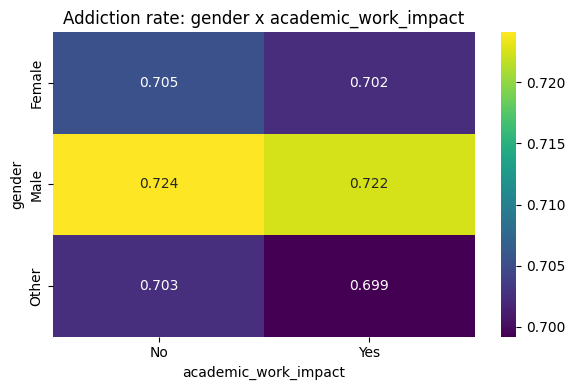


stress_level x academic_work_impact: Addiction rate
academic_work_impact     No    Yes
stress_level                      
High                  0.714  0.709
Low                   0.712  0.710
Medium                0.707  0.705


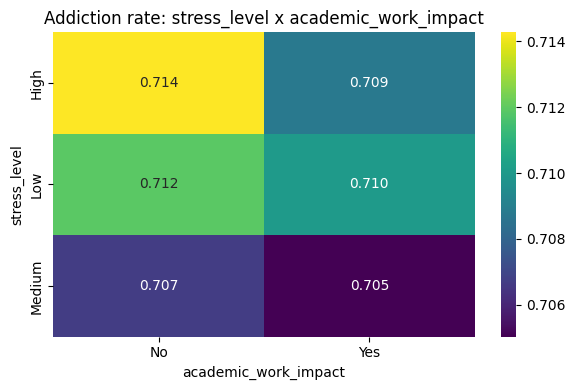

In [48]:
from itertools import combinations

for c1, c2 in combinations(cat_cols, 2):
    ct = train.pivot_table(
        index=c1, columns=c2, values=TARGET, aggfunc="mean"
    )
    print(f"\n{c1} x {c2}: Addiction rate")
    print(ct.round(3))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(f"Addiction rate: {c1} x {c2}")
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/heatmap_{c1}_x_{c2}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# MANN-WHITNEY U TEST

In [39]:
from scipy.stats import mannwhitneyu

mw_rows = []
for c in num_cols:
    a = train.loc[train[TARGET] == 1, c].dropna()
    b = train.loc[train[TARGET] == 0, c].dropna()

    if len(a) == 0 or len(b) == 0:
        continue

    # 'auto' picks continuity correction / exact method based on sample size
    stat, p = mannwhitneyu(a, b, alternative="two-sided", method="auto")

    n1, n2 = len(a), len(b)
    # rank-biserial: sign convention rbc > 0 means group 1 tends to be higher
    rbc = (2 * stat) / (n1 * n2) - 1

    mw_rows.append({
        "feature": c,
        "n_yes": n1,
        "n_no": n2,
        "U": stat,
        "p_value": p,
        "rank_biserial": rbc,
        "median_yes": a.median(),
        "median_no": b.median(),
        "median_diff": a.median() - b.median(),
    })

mw_df = (
    pd.DataFrame(mw_rows)
    .sort_values("rank_biserial", key=lambda s: s.abs(), ascending=False)
)
print(mw_df.round(4).to_string(index=False))
mw_df.to_csv(f"{PLOT_PATH}/mannwhitney_results.csv", index=False)

                feature  n_yes   n_no            U  p_value  rank_biserial  median_yes  median_no  median_diff
daily_screen_time_hours 422293 173222 6.507100e+10   0.0000         0.7791        9.07       5.04         4.03
    weekend_screen_time 410836 168470 6.097630e+10   0.0000         0.7620       10.79       6.82         3.97
     social_media_hours 395416 161958 5.493304e+10   0.0000         0.7156        2.82       1.29         1.53
       work_study_hours 453863 185988 5.528043e+10   0.0000         0.3098        2.47       1.75         0.72
           gaming_hours 400367 164181 4.088306e+10   0.0000         0.2439        1.48       1.07         0.41
      app_opens_per_day 432945 177714 4.161574e+10   0.0000         0.0818      109.00      99.00        10.00
            sleep_hours 458743 188146 4.548166e+10   0.0000         0.0539        6.84       6.72         0.12
  notifications_per_day 442473 181312 3.948262e+10   0.0000        -0.0157      150.00     154.00        -4.00
 

# TARGET ENCODING PREVIEW (with smoothing)

In [40]:
prior = train[TARGET].mean()
k = 20  # smoothing factor

for c in cat_cols:
    g = train.groupby(c)[TARGET].agg(["mean", "count"])
    g["smoothed"] = (g["count"] * g["mean"] + k * prior) / (g["count"] + k)
    g = g.sort_values("smoothed", ascending=False)
    print(f"\n{c} target encoding (smoothed, k={k}):")
    print(g.round(4))


gender target encoding (smoothed, k=20):
          mean   count  smoothed
gender                          
Male    0.7232  223662    0.7232
Female  0.7038  221595    0.7038
Other   0.7010  217078    0.7010

stress_level target encoding (smoothed, k=20):
                mean   count  smoothed
stress_level                          
High          0.7114  220873    0.7114
Low           0.7112  207783    0.7112
Medium        0.7057  207565    0.7057

academic_work_impact target encoding (smoothed, k=20):
                        mean   count  smoothed
academic_work_impact                          
No                    0.7110  316579    0.7110
Yes                   0.7079  330566    0.7079


# USELESS FEATURE DETECTION

In [41]:
report = []
for c in num_cols + cat_cols:
    nunique = train[c].nunique(dropna=False)
    top_share = train[c].value_counts(normalize=True, dropna=False).iloc[0]
    report.append({
        "feature": c,
        "nunique": nunique,
        "top_value_share": round(top_share, 4),
        "is_constant": nunique == 1,
        "is_near_constant": top_share > 0.99,
    })
print(pd.DataFrame(report).to_string(index=False))

                feature  nunique  top_value_share  is_constant  is_near_constant
                    age       19           0.0631        False             False
daily_screen_time_hours     1390           0.1386        False             False
     social_media_hours      722           0.1938        False             False
           gaming_hours      402           0.1834        False             False
       work_study_hours      601           0.0745        False             False
            sleep_hours      452           0.0643        False             False
  notifications_per_day      232           0.0978        False             False
      app_opens_per_day      167           0.1167        False             False
    weekend_screen_time     1438           0.1621        False             False
                 gender        4           0.3235        False             False
           stress_level        4           0.3195        False             False
   academic_work_impact     

# TRAIN/TEST DISTRIBUTION SHIFT (KS TEST)

                feature  n_train  n_test  KS_stat  p_value
  notifications_per_day   623785  262081   0.0027   0.1400
            sleep_hours   646889  273847   0.0022   0.3192
           gaming_hours   564548  236882   0.0021   0.4598
      app_opens_per_day   610659  270597   0.0021   0.3894
daily_screen_time_hours   595515  263514   0.0017   0.6467
    weekend_screen_time   579306  245605   0.0017   0.7202
     social_media_hours   557374  248905   0.0016   0.7703
                    age   662440  279164   0.0014   0.8041
       work_study_hours   639851  268525   0.0009   0.9973


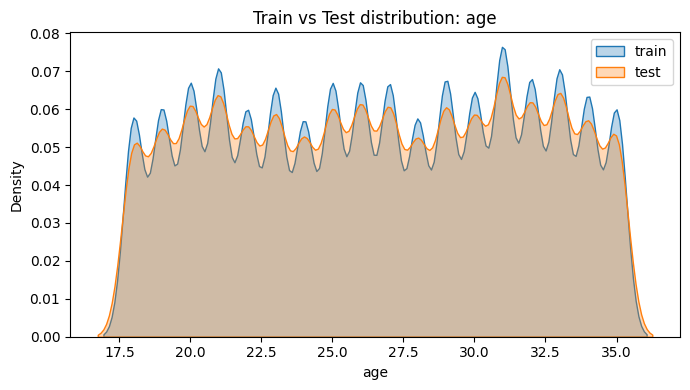

<Figure size 640x480 with 0 Axes>

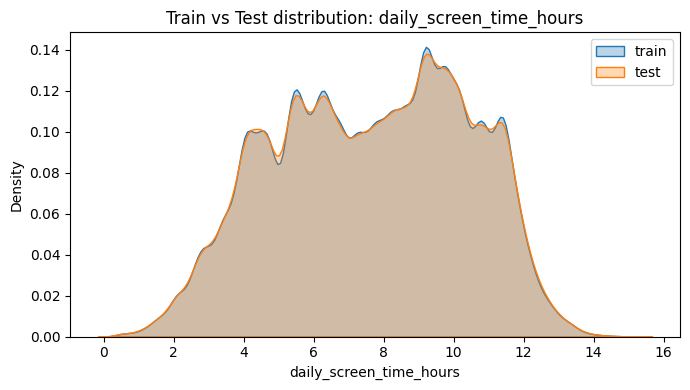

<Figure size 640x480 with 0 Axes>

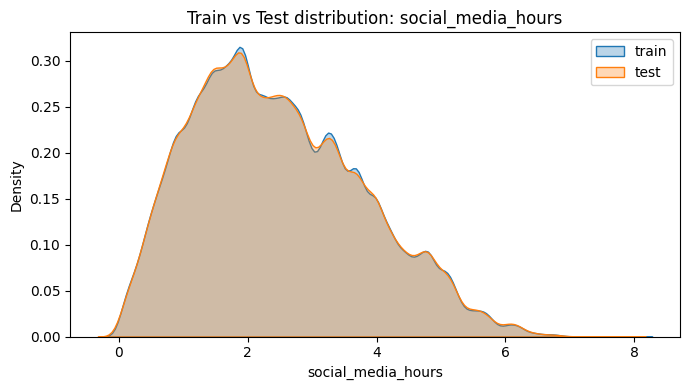

<Figure size 640x480 with 0 Axes>

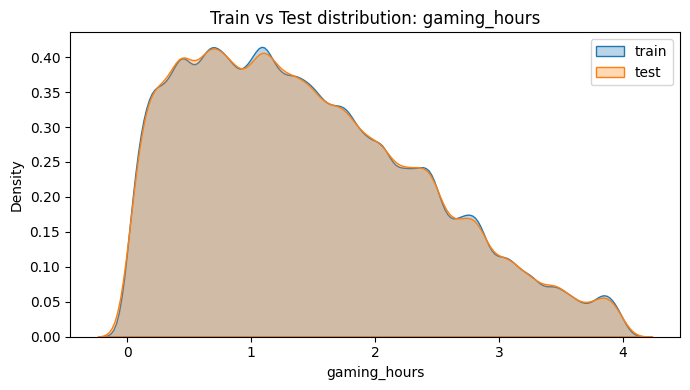

<Figure size 640x480 with 0 Axes>

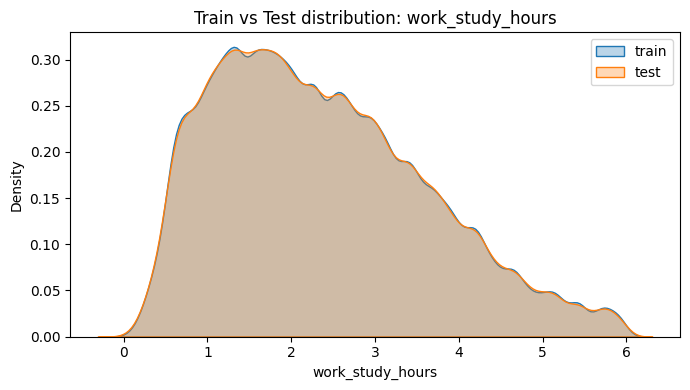

<Figure size 640x480 with 0 Axes>

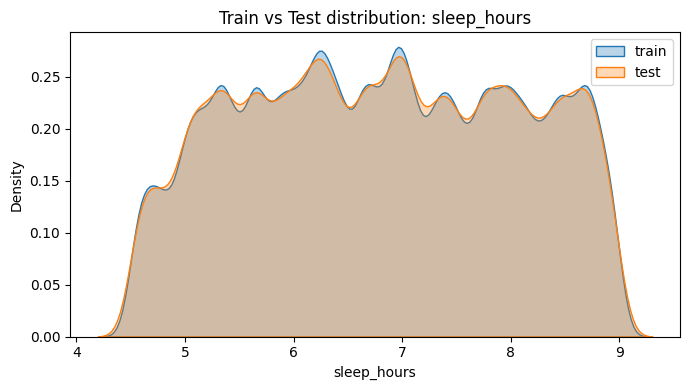

<Figure size 640x480 with 0 Axes>

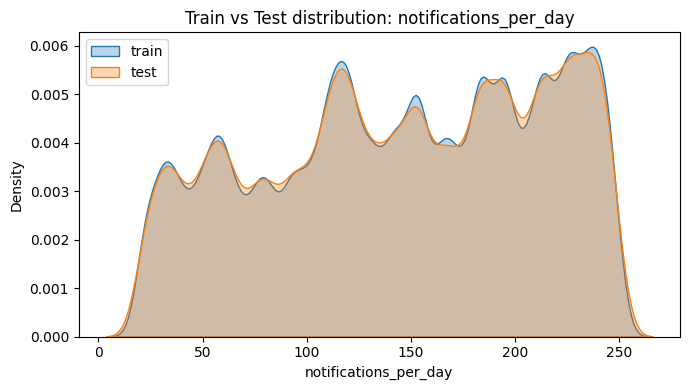

<Figure size 640x480 with 0 Axes>

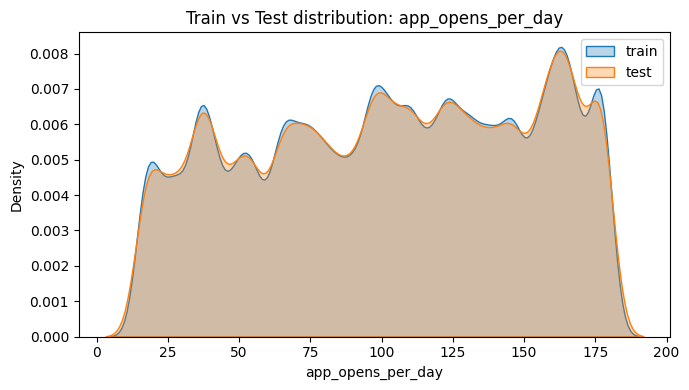

<Figure size 640x480 with 0 Axes>

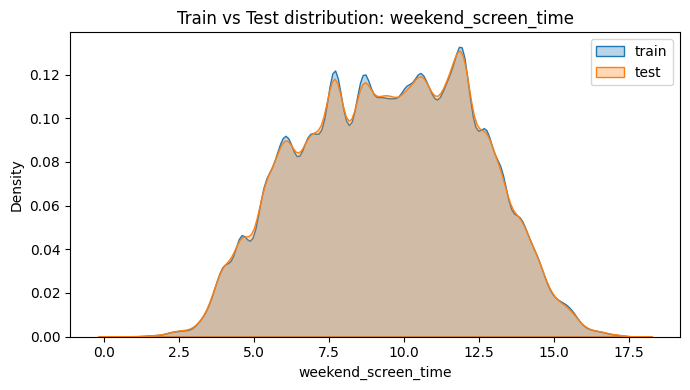

<Figure size 640x480 with 0 Axes>

In [47]:
from scipy.stats import ks_2samp

shift_rows = []
for c in num_cols:
    a = train[c].dropna()
    b = test[c].dropna()

    if len(a) == 0 or len(b) == 0:
        continue

    stat, p = ks_2samp(a, b)
    shift_rows.append({
        "feature": c,
        "n_train": len(a),
        "n_test": len(b),
        "KS_stat": stat,
        "p_value": p,
    })

shift_df = (
    pd.DataFrame(shift_rows)
    .sort_values("KS_stat", ascending=False)
    .round(4)
)
print(shift_df.to_string(index=False))
shift_df.to_csv(f"{PLOT_PATH}/train_test_shift.csv", index=False)

for c in num_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.kdeplot(train[c], label="train", ax=ax, fill=True, alpha=0.3)
    sns.kdeplot(test[c],  label="test",  ax=ax, fill=True, alpha=0.3)
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{PLOT_PATH}/shift_{c}.png", dpi=110, bbox_inches="tight")
    plt.close(fig)

# KDE OVERLAY: TRAIN (Addicted/no-Addicted) vs TEST

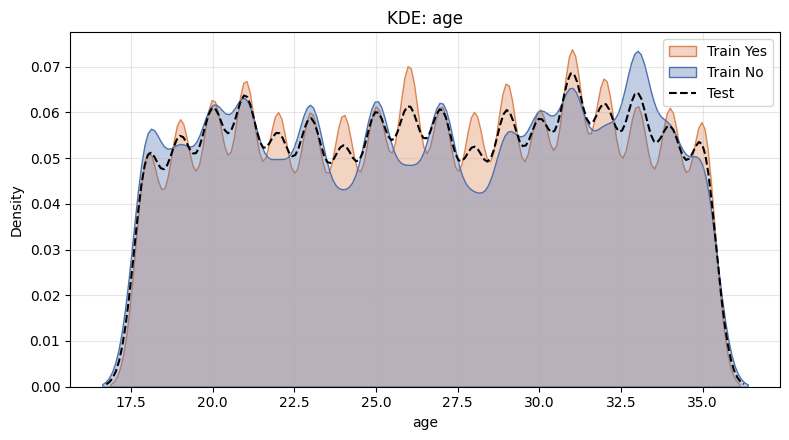

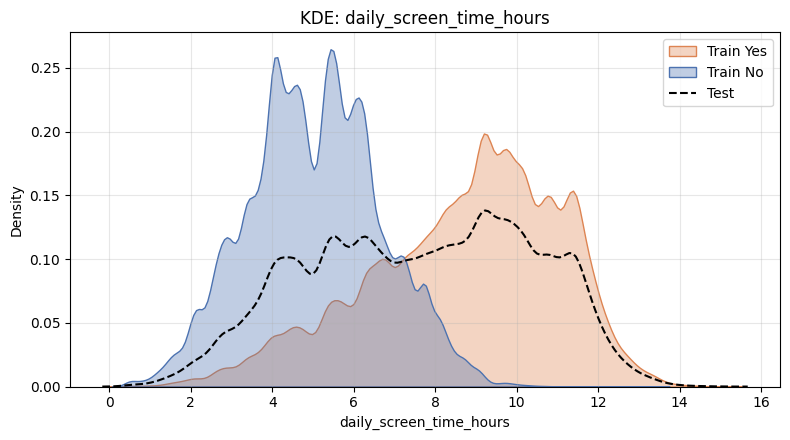

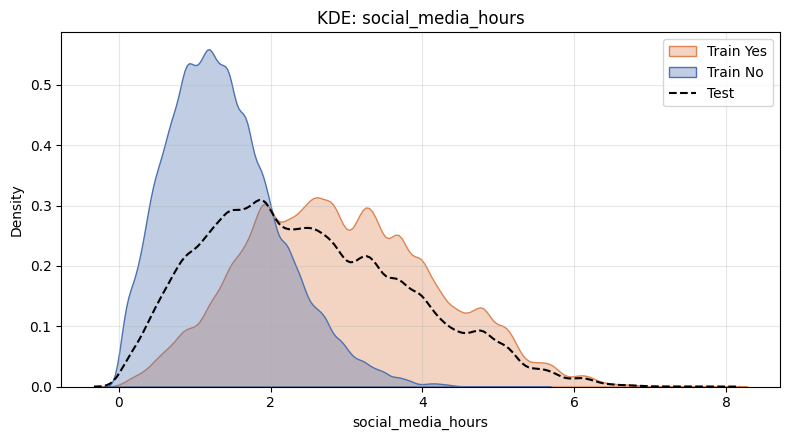

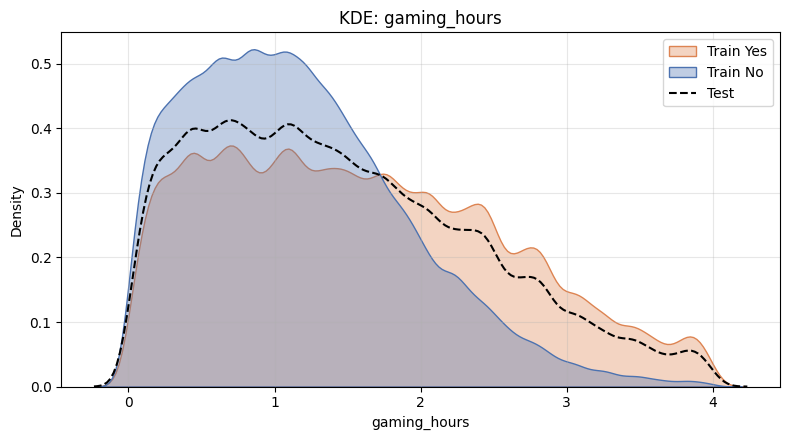

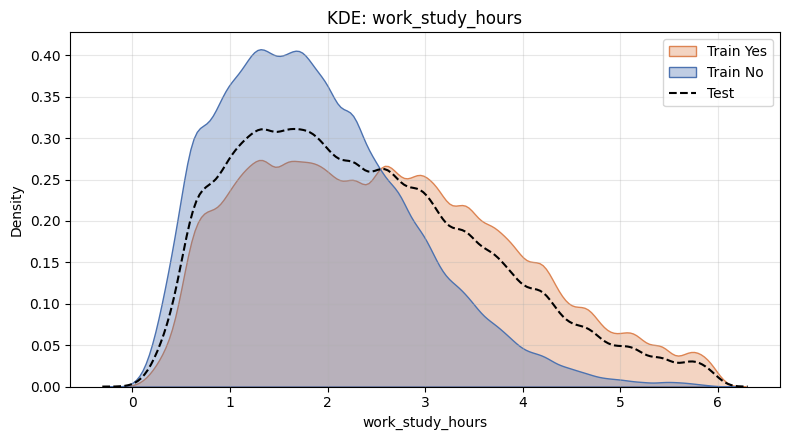

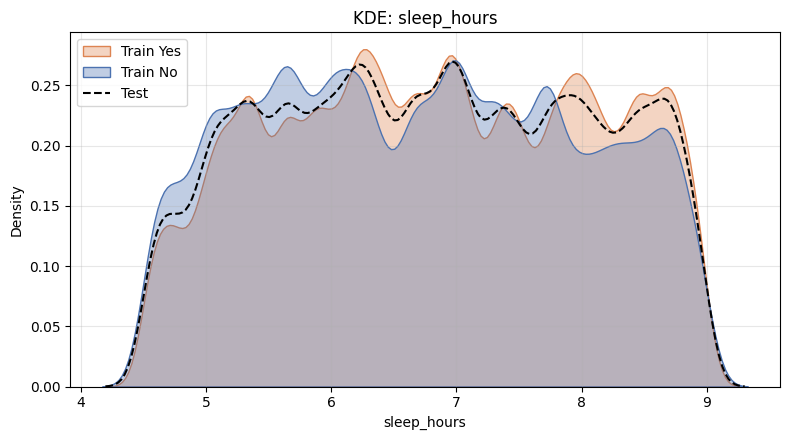

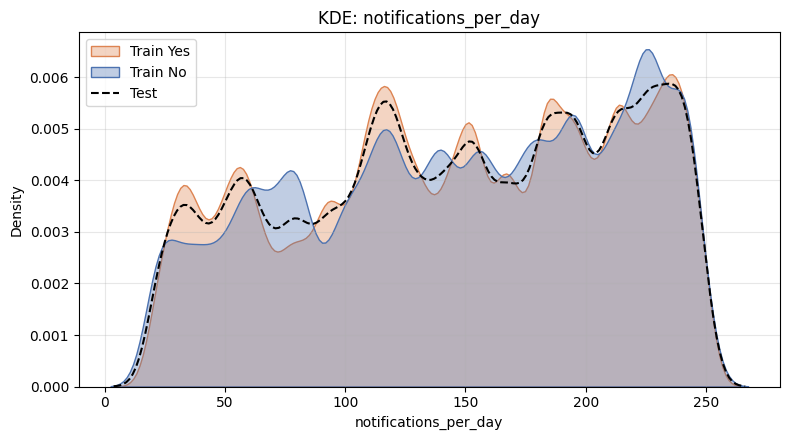

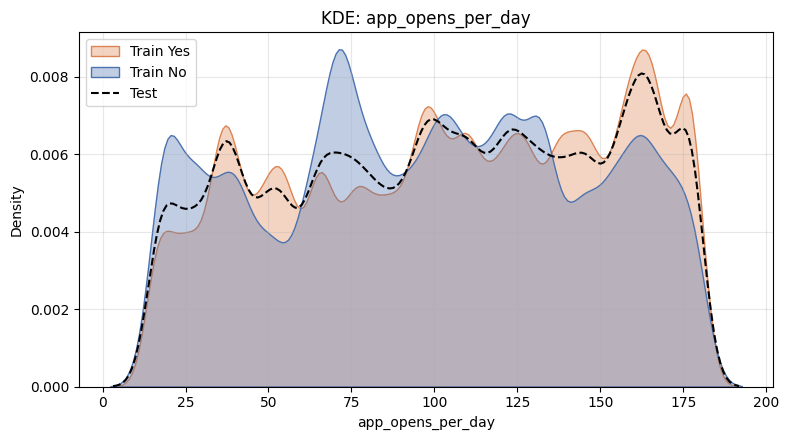

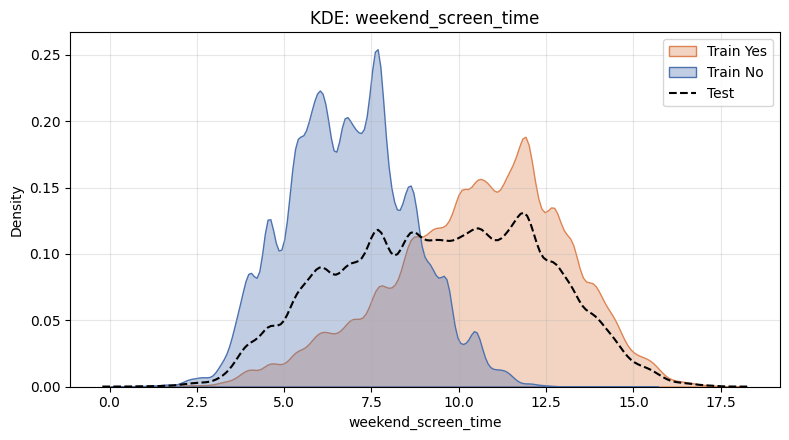

In [46]:
for c in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.kdeplot(train.loc[train[TARGET] == 1, c], label="Train Yes",
                ax=ax, fill=True, alpha=0.35, color="#DD8452")
    sns.kdeplot(train.loc[train[TARGET] == 0, c], label="Train No",
                ax=ax, fill=True, alpha=0.35, color="#4C72B0")
    sns.kdeplot(test[c], label="Test", ax=ax, color="black", ls="--")
    ax.set_title(f"KDE: {c}")
    ax.set_xlabel(c)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/kde_{c}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# UNIFIED SIGNAL TABLE

                feature type  mutual_info  pearson  rank_biserial  cramers_v
daily_screen_time_hours  num       0.2241   0.6114         0.7791        NaN
    weekend_screen_time  num       0.2065   0.5899         0.7620        NaN
     social_media_hours  num       0.1603   0.5324         0.7156        NaN
  notifications_per_day  num       0.0866  -0.0116        -0.0157        NaN
      app_opens_per_day  num       0.0789   0.0635         0.0818        NaN
       work_study_hours  num       0.0419   0.2514         0.3098        NaN
           gaming_hours  num       0.0297   0.2053         0.2439        NaN
            sleep_hours  num       0.0126   0.0425         0.0539        NaN
                    age  num       0.0091   0.0040         0.0045        NaN
                 gender  cat       0.0002      NaN            NaN     0.0218
           stress_level  cat       0.0000      NaN            NaN     0.0058
   academic_work_impact  cat       0.0000      NaN            NaN     0.0035

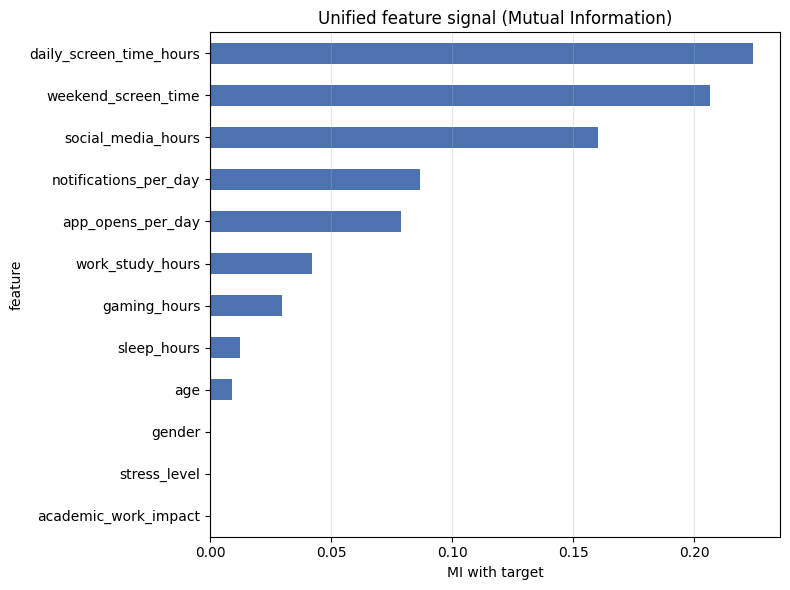

In [45]:
pearson = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)

rows = []
for c in num_cols + cat_cols:
    if c in num_cols:
        pear = pearson.get(c, np.nan)
        mw = mw_df.set_index("feature").loc[c, "rank_biserial"] if c in mw_df["feature"].values else np.nan
        cram = np.nan
    else:
        pear = np.nan
        mw = np.nan
        cram = chi_df.set_index("feature").loc[c, "cramers_v"] if c in chi_df["feature"].values else np.nan
    rows.append({
        "feature": c,
        "type": "num" if c in num_cols else "cat",
        "mutual_info": mi_series.get(c, np.nan),
        "pearson": pear,
        "rank_biserial": mw,
        "cramers_v": cram,
    })

signal = pd.DataFrame(rows).sort_values("mutual_info", ascending=False)
print(signal.round(4).to_string(index=False))
signal.to_csv(f"{PLOT_PATH}/signal_summary.csv", index=False)

# Bar chart of MI for a visual
fig, ax = plt.subplots(figsize=(8, 6))
signal.set_index("feature")["mutual_info"].plot.barh(ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Unified feature signal (Mutual Information)")
ax.set_xlabel("MI with target")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/signal_summary.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()